# **Farneback optical flow density**

In [ ]:
import cv2
import numpy as np
import os
from glob import glob
from tqdm import tqdm

def flow_features(prev_gray, gray, grid=(16,16), mag_thresh=0.8):
    flow = cv2.calcOpticalFlowFarneback(prev_gray, gray, None,
                                        0.5, 3, 15, 3, 5, 1.2, 0)
    fx, fy = flow[...,0], flow[...,1]
    mag, ang = cv2.cartToPolar(fx, fy, angleInDegrees=False)

    active = (mag > mag_thresh).astype(np.uint8)
    density = active.mean()

    mag_mean, mag_std = mag.mean(), mag.std()
    hist, _ = np.histogram(mag, bins=32, range=(0, np.clip(mag.max(),1e-6,10)))
    p = hist / (hist.sum() + 1e-12)
    entropy = -(p[p>0] * np.log(p[p>0])).sum()

    ux, uy = np.cos(ang), np.sin(ang)
    R = np.sqrt(ux.mean()**2 + uy.mean()**2)
    dir_var = 1 - R

    pressure = density * mag_mean

    H, W = mag.shape
    gh, gw = grid
    cell_h, cell_w = H//gh, W//gw
    heat = np.zeros((gh, gw), dtype=np.float32)
    for i in range(gh):
        for j in range(gw):
            y0,y1 = i*cell_h, (i+1)*cell_h
            x0,x1 = j*cell_w, (j+1)*cell_w
            cell = active[y0:y1, x0:x1]
            heat[i,j] = cell.mean()

    feat_vec = np.array([density, mag_mean, mag_std, entropy, dir_var, pressure], dtype=np.float32)
    return feat_vec, heat

def process_image_sequence(img_dir, out_dir, grid=(16,16)):
    img_files = sorted(glob(os.path.join(img_dir, "*.jpg")) +
                       glob(os.path.join(img_dir, "*.png")))
    if len(img_files) < 2:
        print(f"Not enough frames in {img_dir}")
        return

    feat_list, heat_list = [], []
    prev_frame = cv2.imread(img_files[0])
    prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)

    for img_path in img_files[1:]:
        frame = cv2.imread(img_path)
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        feat_vec, heat = flow_features(prev_gray, gray, grid)
        feat_list.append(feat_vec)
        heat_list.append(heat)
        prev_gray = gray

    feat_arr = np.stack(feat_list)
    heat_arr = np.stack(heat_list)

    base = os.path.basename(os.path.dirname(img_dir))  # e.g. MOT20-01
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, f"{base}_flow.npz")

    np.savez_compressed(out_path, features=feat_arr, heatmaps=heat_arr)
    print(f"Saved: {out_path} | Features: {feat_arr.shape}, Heatmaps: {heat_arr.shape}")

if __name__ == "__main__":
    root_dir = "/content/drive/MyDrive/Store/MOT20/train"  # contains MOT20-01, MOT20-02, etc.
    out_dir = "/content/drive/MyDrive/Store/L2Farneback_features"

    seq_dirs = [os.path.join(root_dir, d, "img1")
                for d in os.listdir(root_dir)
                if os.path.isdir(os.path.join(root_dir, d, "img1"))]

    for seq in tqdm(seq_dirs):
        process_image_sequence(seq, out_dir)


 25%|██▌       | 1/4 [06:01<18:05, 361.78s/it]

Saved: /content/drive/MyDrive/Colab_Notebooks/L2Farneback_features/MOT20-01_flow.npz | Features: (428, 6), Heatmaps: (428, 16, 16)


 50%|█████     | 2/4 [52:27<59:35, 1787.60s/it]

Saved: /content/drive/MyDrive/Colab_Notebooks/L2Farneback_features/MOT20-05_flow.npz | Features: (3314, 6), Heatmaps: (3314, 16, 16)


 75%|███████▌  | 3/4 [1:38:14<37:05, 2225.87s/it]

Saved: /content/drive/MyDrive/Colab_Notebooks/L2Farneback_features/MOT20-02_flow.npz | Features: (2781, 6), Heatmaps: (2781, 16, 16)


100%|██████████| 4/4 [1:59:23<00:00, 1790.85s/it]

Saved: /content/drive/MyDrive/Colab_Notebooks/L2Farneback_features/MOT20-03_flow.npz | Features: (2434, 6), Heatmaps: (2434, 16, 16)


## example

In [ ]:
import cv2
import numpy as np

def flow_features(prev_gray, gray, grid=(16,16), mag_thresh=0.8):
    flow = cv2.calcOpticalFlowFarneback(prev_gray, gray, None,
                                        0.5, 3, 15, 3, 5, 1.2, 0)
    fx, fy = flow[...,0], flow[...,1]
    mag, ang = cv2.cartToPolar(fx, fy, angleInDegrees=False)

    active = (mag > mag_thresh).astype(np.uint8)
    density = active.mean()

    mag_mean, mag_std = mag.mean(), mag.std()
    hist, _ = np.histogram(mag, bins=32, range=(0, np.clip(mag.max(),1e-6,10)))
    p = hist / (hist.sum() + 1e-12)
    entropy = -(p[p>0] * np.log(p[p>0])).sum()

    ux, uy = np.cos(ang), np.sin(ang)
    R = np.sqrt(ux.mean()**2 + uy.mean()**2)
    dir_var = 1 - R

    pressure = density * mag_mean

    H, W = mag.shape
    gh, gw = grid
    cell_h, cell_w = H//gh, W//gw
    heat = np.zeros((gh, gw), dtype=np.float32)
    for i in range(gh):
        for j in range(gw):
            y0,y1 = i*cell_h, (i+1)*cell_h
            x0,x1 = j*cell_w, (j+1)*cell_w
            cell = active[y0:y1, x0:x1]
            heat[i,j] = cell.mean()

    feat_vec = np.array([density, mag_mean, mag_std, entropy, dir_var, pressure], dtype=np.float32)
    return feat_vec, heat


# --- TESTING ON JUST TWO FRAMES ---
# replace with any two images from your MOT dataset
img1 = cv2.imread("/content/drive/MyDrive/Store/MOT20/train/MOT20-01/img1/000001.jpg")
img2 = cv2.imread("/content/drive/MyDrive/Store/MOT20/train/MOT20-01/img1/000002.jpg")

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

feat_vec, heat = flow_features(gray1, gray2, grid=(16,16))

print("Feature vector (6 values):", feat_vec)
print("Heatmap shape:", heat.shape)
print("Heatmap (first 3x3 cells):\n", heat[:3,:3])


Feature vector (6 values): [0.29168162 0.7515932  1.2063075  1.838529   0.6016648  0.21922591]
Heatmap shape: (16, 16)
Heatmap (first 3x3 cells):
 [[0.29577115 0.16691542 0.01368159]
 [0.39850748 0.09726368 0.        ]
 [0.30373135 0.5597015  0.37699005]]


# Heuristic Labels

In [ ]:
import numpy as np
import os
from glob import glob
from tqdm import tqdm

def heuristic_labeling(features, density_thresh=0.3, speed_thresh=1.5, entropy_thresh=1.0):
    """
    Assigns heuristic labels based on Farneback features.

    features: np.ndarray -> shape (N, 6)
    Columns: [density, mag_mean, mag_std, entropy, dir_var, pressure]
    """
    labels = []
    for f in features:
        density, mag_mean, mag_std, entropy, dir_var, pressure = f
        risk_score = 0

        # Rule 1: too crowded
        if density > density_thresh:
            risk_score += 1

        # Rule 2: too much average movement
        if mag_mean > speed_thresh:
            risk_score += 1

        # Rule 3: chaotic movement (entropy high or directions varied)
        if entropy > entropy_thresh or dir_var > 0.5:
            risk_score += 1

        # Assign label
        label = 1 if risk_score >= 2 else 0  # 1 = risky, 0 = safe
        labels.append(label)

    return np.array(labels, dtype=np.int64)

def process_npz_files(in_dir, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    npz_files = glob(os.path.join(in_dir, "*_flow.npz"))

    for fpath in tqdm(npz_files):
        data = np.load(fpath)
        features = data["features"]
        heatmaps = data["heatmaps"]

        labels = heuristic_labeling(features)

        base = os.path.basename(fpath).replace("_flow.npz", "")
        out_path = os.path.join(out_dir, f"{base}_heuristic.npz")

        np.savez_compressed(out_path, features=features, heatmaps=heatmaps, labels=labels)
        print(f"Saved: {out_path} | Features: {features.shape}, Heatmaps: {heatmaps.shape}, Labels: {labels.shape}")

if __name__ == "__main__":
    in_dir = "/content/drive/MyDrive/Store/L2Farneback_features"
    out_dir = "/content/drive/MyDrive/Store/L2Heuristic_labels"

    process_npz_files(in_dir, out_dir)


 25%|██▌       | 1/4 [00:00<00:01,  2.46it/s]

Saved: /content/drive/MyDrive/Store/L2Heuristic_labels/MOT20-01_heuristic.npz | Features: (428, 6), Heatmaps: (428, 16, 16), Labels: (428,)


 50%|█████     | 2/4 [00:01<00:01,  1.32it/s]

Saved: /content/drive/MyDrive/Store/L2Heuristic_labels/MOT20-05_heuristic.npz | Features: (3314, 6), Heatmaps: (3314, 16, 16), Labels: (3314,)


 75%|███████▌  | 3/4 [00:02<00:00,  1.36it/s]

Saved: /content/drive/MyDrive/Store/L2Heuristic_labels/MOT20-02_heuristic.npz | Features: (2781, 6), Heatmaps: (2781, 16, 16), Labels: (2781,)


100%|██████████| 4/4 [00:02<00:00,  1.40it/s]

Saved: /content/drive/MyDrive/Store/L2Heuristic_labels/MOT20-03_heuristic.npz | Features: (2434, 6), Heatmaps: (2434, 16, 16), Labels: (2434,)


# **LSTM**

In [ ]:
import os
# ============================
# CONFIG
# ============================
DATA_DIR = "/content/drive/MyDrive/Store/L2Heuristic_labels"  # where *_heuristic.npz live
MODEL_DIR = "/content/drive/MyDrive/Store/L2Models"
os.makedirs(MODEL_DIR, exist_ok=True)
WINDOW = 32      # frames per sample
STRIDE = 8      # hop between windows
BATCH_SIZE = 8
EPOCHS = 12
VAL_SPLIT = 0.2
SEED = 42

import os, glob, json, math, random
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout, Concatenate,
                                     ConvLSTM2D, BatchNormalization, Flatten,
                                     GlobalAveragePooling2D)
from tensorflow.keras.models import Model
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# ============================
# 1) LOAD & WINDOW THE DATA
# ============================
def load_npz_list(data_dir):
    return sorted(glob.glob(os.path.join(data_dir, "*_heuristic.npz")))

def make_windows(features, heatmaps, labels, window=64, stride=16, label_mode="max"):
    """
    features: (T, 6)
    heatmaps: (T, 16, 16)
    labels:   (T,)
    Returns lists of windowed samples.
    label_mode: 'max' (risk if any risky frame in window) or 'last' or 'majority'
    """
    T = len(labels)
    Xf_list, Xh_list, y_list = [], [], []
    for start in range(0, max(T - window + 1, 0), stride):
        end = start + window
        xf = features[start:end]                # (W, 6)
        xh = heatmaps[start:end][..., None]     # (W, 16,16,1)
        yl = labels[start:end]                  # (W,)

        if len(xf) < window:  # safety
            continue

        if label_mode == "max":
            y = int(yl.max())
        elif label_mode == "last":
            y = int(yl[-1])
        else:  # majority
            y = int((yl.sum() >= (len(yl)/2)))

        Xf_list.append(xf.astype(np.float32))
        Xh_list.append(xh.astype(np.float32))
        y_list.append(y)

    return Xf_list, Xh_list, y_list

all_files = load_npz_list(DATA_DIR)
print(f"Found {len(all_files)} sequences.")

Xf_all, Xh_all, y_all = [], [], []
for fp in all_files:
    d = np.load(fp)
    features = d["features"]            # (T, 6)
    heatmaps = d["heatmaps"]            # (T, 16, 16)
    labels   = d["labels"]              # (T,)
    xf, xh, y = make_windows(features, heatmaps, labels,
                             window=WINDOW, stride=STRIDE, label_mode="max")
    Xf_all.extend(xf)
    Xh_all.extend(xh)
    y_all.extend(y)

Xf_all = np.stack(Xf_all)            # (N, W, 6)
Xh_all = np.stack(Xh_all)            # (N, W, 16, 16, 1)
y_all  = np.array(y_all, np.int64)   # (N,)
print("Windowed shapes:", Xf_all.shape, Xh_all.shape, y_all.shape)

# ============================
# 2) NORMALIZE FEATURES
# ============================
# Per-feature mean/std computed from training split only
Xf_train_raw, Xf_val_raw, Xh_train, Xh_val, y_train, y_val = train_test_split(
    Xf_all, Xh_all, y_all, test_size=VAL_SPLIT, random_state=SEED, stratify=y_all
)

import collections
print("Full dataset label balance:", collections.Counter(y_all))
print("Train split balance:", collections.Counter(y_train))
print("Val split balance:", collections.Counter(y_val))


feat_mean = Xf_train_raw.reshape(-1, Xf_train_raw.shape[-1]).mean(axis=0)
feat_std  = Xf_train_raw.reshape(-1, Xf_train_raw.shape[-1]).std(axis=0) + 1e-6

def norm_feats(x): return (x - feat_mean) / feat_std

Xf_train = norm_feats(Xf_train_raw)
Xf_val   = norm_feats(Xf_val_raw)

# Save normalization stats for inference
norm_path = os.path.join(DATA_DIR, "feature_norm.json")
with open(norm_path, "w") as f:
    json.dump({"mean": feat_mean.tolist(), "std": feat_std.tolist()}, f)
print("Saved normalization stats ->", norm_path)

# ============================
# 3) TF DATASETS
# ============================
train_ds = tf.data.Dataset.from_tensor_slices(((Xf_train, Xh_train), y_train))
val_ds   = tf.data.Dataset.from_tensor_slices(((Xf_val,   Xh_val),   y_val))

train_ds = train_ds.shuffle(2048, seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# ============================
# 4) CLASS WEIGHTS (optional)
# ============================
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}
print("Class weights:", class_weight_dict)

# ============================
# 5) BUILD MODEL (ConvLSTM + LSTM)
# ============================
def build_model(window=WINDOW):
    # LSTM branch on numeric features (W,6)
    in_feat = Input(shape=(window, 6), name="features")
    fx = LSTM(64, return_sequences=False)(in_feat)
    fx = Dense(64, activation="relu")(fx)

    # ConvLSTM branch on heatmaps (W,16,16,1)
    in_heat = Input(shape=(window, 16, 16, 1), name="heatmaps")
    hx = ConvLSTM2D(32, (3,3), padding="same", return_sequences=True)(in_heat)
    hx = BatchNormalization()(hx)
    hx = ConvLSTM2D(64, (3,3), padding="same", return_sequences=False)(hx)
    hx = BatchNormalization()(hx)
    # Spatial pooling → compact representation
    hx = GlobalAveragePooling2D()(hx)       # (64,)

    # Fusion
    z = Concatenate()([fx, hx])             # (64+64)
    z = Dense(128, activation="relu")(z)
    z = Dropout(0.3)(z)
    out = Dense(1, activation="sigmoid")(z)

    model = Model(inputs=[in_feat, in_heat], outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=[tf.keras.metrics.AUC(name="auc"),
                           tf.keras.metrics.Precision(name="precision"),
                           tf.keras.metrics.Recall(name="recall"),
                           "accuracy"])
    return model

model = build_model(WINDOW)
model.summary()

# ============================
# 6) TRAIN
# ============================
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(MODEL_DIR, "dual_branch_best.keras"),
        monitor="val_auc", mode="max", save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=5, restore_best_weights=True, verbose=1)
]

history = model.fit(
    {"features": Xf_train, "heatmaps": Xh_train}, y_train,
    validation_data=({"features": Xf_val, "heatmaps": Xh_val}, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

# Save final model
final_path = os.path.join(MODEL_DIR, "dual_branch_final.keras")
model.save(final_path)
print("Saved model ->", final_path)

# ============================
# 7) SIMPLE INFERENCE HELPER
# ============================
def predict_sequence(features_window, heatmaps_window, model, mean, std):
    """
    features_window: (W,6), heatmaps_window: (W,16,16,1)
    Returns risk score in [0,1]
    """
    f = (features_window - mean) / (std + 1e-6)
    f = np.expand_dims(f.astype(np.float32), 0)
    h = np.expand_dims(heatmaps_window.astype(np.float32), 0)
    prob = model.predict({"features": f, "heatmaps": h}, verbose=0)[0,0]
    return float(prob)

# Example on a random validation sample
idx = np.random.randint(0, Xf_val.shape[0])
demo_prob = predict_sequence(Xf_val_raw[idx], Xh_val[idx], model, feat_mean, feat_std)  # note: use RAW feats before norm
print(f"Demo risk prob = {demo_prob:.3f}, true label = {y_val[idx]}")


Found 4 sequences.
Windowed shapes: (1106, 32, 6) (1106, 32, 16, 16, 1) (1106,)
Full dataset label balance: Counter({np.int64(1): 1070, np.int64(0): 36})
Train split balance: Counter({np.int64(1): 855, np.int64(0): 29})
Val split balance: Counter({np.int64(1): 215, np.int64(0): 7})
Saved normalization stats -> /content/drive/MyDrive/Store/L2Heuristic_labels/feature_norm.json
Class weights: {0: 15.241379310344827, 1: 0.5169590643274854}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ heatmaps            │ (None, 32, 16,    │          0 │ -                 │
│ (InputLayer)        │ 16, 1)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d         │ (None, 32, 16,    │     38,144 │ heatmaps[0][0]    │
│ (ConvLSTM2D)        │ 16, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 16,    │        128 │ conv_lstm2d[0][0] │
│ (BatchNormalizatio… │ 16, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ features            │ (None, 32, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_1       │ (None, 16, 16,    │    221,440 │ batch_normalizat… │
│ (ConvLSTM2D)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     18,176 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv_lstm2d_1[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │        129 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 298,945 (1.14 MB)

 Trainable params: 298,753 (1.14 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.7569 - auc: 0.8107 - loss: 0.5106 - precision: 0.9917 - recall: 0.7550
Epoch 1: val_auc improved from -inf to 0.60498, saving model to /content/drive/MyDrive/Store/L3Models/dual_branch_best.keras
111/111 ━━━━━━━━━━━━━━━━━━━━ 39s 251ms/step - accuracy: 0.7572 - auc: 0.8116 - loss: 0.5095 - precision: 0.9917 - recall: 0.7554 - val_accuracy: 0.9685 - val_auc: 0.6050 - val_loss: 0.1769 - val_precision: 0.9685 - val_recall: 1.0000
Epoch 2/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.8537 - auc: 0.9289 - loss: 0.3091 - precision: 0.9968 - recall: 0.8517
Epoch 2: val_auc improved from 0.60498 to 0.85083, saving model to /content/drive/MyDrive/Store/L3Models/dual_branch_best.keras
111/111 ━━━━━━━━━━━━━━━━━━━━ 32s 220ms/step - accuracy: 0.8536 - auc: 0.9289 - loss: 0.3091 - precision: 0.9968 - recall: 0.8516 - val_accuracy: 0.6441 - val_auc: 0.8508 - val_loss: 1.0522 - val_precision: 0.9928 - val_recall: 0.6372
E

## visualization

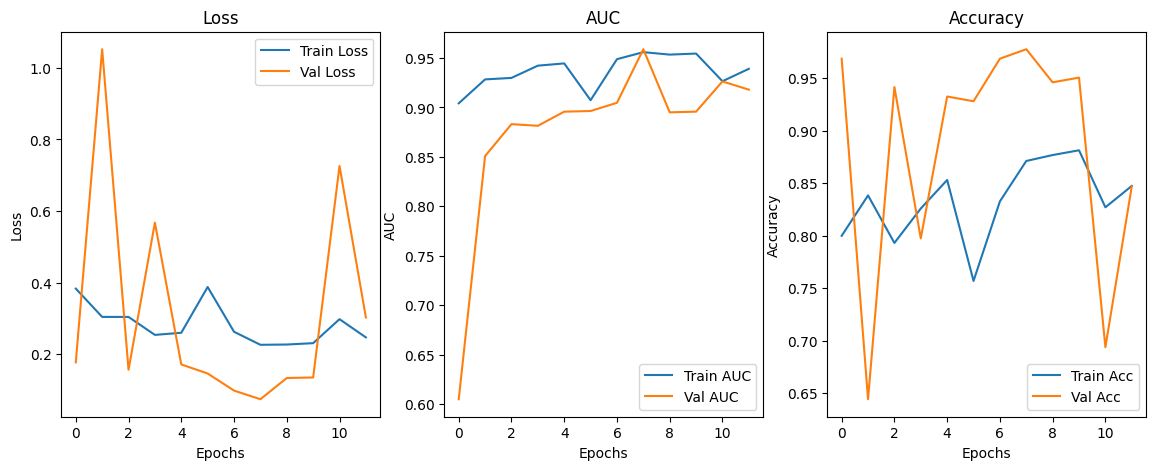

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step


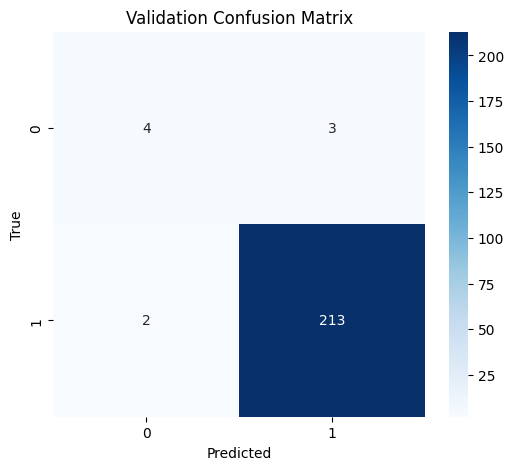

              precision    recall  f1-score   support

           0      0.667     0.571     0.615         7
           1      0.986     0.991     0.988       215

    accuracy                          0.977       222
   macro avg      0.826     0.781     0.802       222
weighted avg      0.976     0.977     0.977       222



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ============================
# 8) TRAINING CURVES
# ============================
plt.figure(figsize=(14,5))

# Loss
plt.subplot(1,3,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs"); plt.ylabel("Loss")
plt.legend(); plt.title("Loss")

# AUC
plt.subplot(1,3,2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.xlabel("Epochs"); plt.ylabel("AUC")
plt.legend(); plt.title("AUC")

# Accuracy
plt.subplot(1,3,3)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel("Epochs"); plt.ylabel("Accuracy")
plt.legend(); plt.title("Accuracy")

plt.show()

# ============================
# 9) CONFUSION MATRIX + REPORT
# ============================
y_val_pred = (model.predict({"features": Xf_val, "heatmaps": Xh_val}) > 0.5).astype(int)

cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Validation Confusion Matrix")
plt.show()

print(classification_report(y_val, y_val_pred, digits=3))


## majority instead of max as label_mode

Found 4 sequences.
Windowed shapes: (1106, 32, 6) (1106, 32, 16, 16, 1) (1106,)
Full dataset label balance: Counter({np.int64(1): 685, np.int64(0): 421})
Train split balance: Counter({np.int64(1): 548, np.int64(0): 336})
Val split balance: Counter({np.int64(1): 137, np.int64(0): 85})
Saved normalization stats -> /content/drive/MyDrive/Store/L2Heuristic_labels/feature_norm.json
Class weights: {0: 1.3154761904761905, 1: 0.8065693430656934}


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ heatmaps            │ (None, 32, 16,    │          0 │ -                 │
│ (InputLayer)        │ 16, 1)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_2       │ (None, 32, 16,    │     38,144 │ heatmaps[0][0]    │
│ (ConvLSTM2D)        │ 16, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 16,    │        128 │ conv_lstm2d_2[0]… │
│ (BatchNormalizatio… │ 16, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ features            │ (None, 32, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_3       │ (None, 16, 16,    │    221,440 │ batch_normalizat… │
│ (ConvLSTM2D)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     18,176 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv_lstm2d_3[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      4,160 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128)       │          0 │ dense_3[0][0],    │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     16,512 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │        129 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 298,945 (1.14 MB)

 Trainable params: 298,753 (1.14 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.9137 - auc: 0.9678 - loss: 0.2479 - precision: 0.9875 - recall: 0.8619
Epoch 1: val_auc improved from -inf to 0.98038, saving model to /content/drive/MyDrive/Store/models/L2Models/dual_branch_best.keras
111/111 ━━━━━━━━━━━━━━━━━━━━ 34s 237ms/step - accuracy: 0.9140 - auc: 0.9679 - loss: 0.2470 - precision: 0.9875 - recall: 0.8625 - val_accuracy: 0.9459 - val_auc: 0.9804 - val_loss: 0.2171 - val_precision: 0.9921 - val_recall: 0.9197
Epoch 2/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.9676 - auc: 0.9916 - loss: 0.0904 - precision: 0.9917 - recall: 0.9541
Epoch 2: val_auc improved from 0.98038 to 0.99395, saving model to /content/drive/MyDrive/Store/models/L2Models/dual_branch_best.keras
111/111 ━━━━━━━━━━━━━━━━━━━━ 39s 223ms/step - accuracy: 0.9676 - auc: 0.9917 - loss: 0.0903 - precision: 0.9917 - recall: 0.9541 - val_accuracy: 0.9505 - val_auc: 0.9939 - val_loss: 0.1301 - val_precision: 0.9632 - val_re

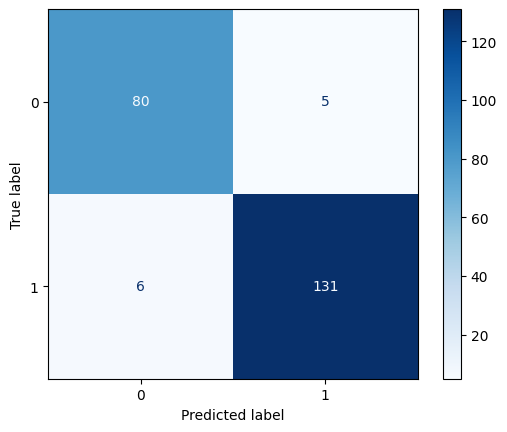

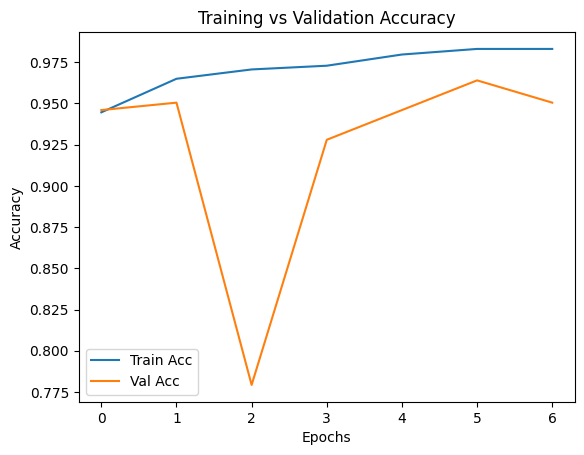

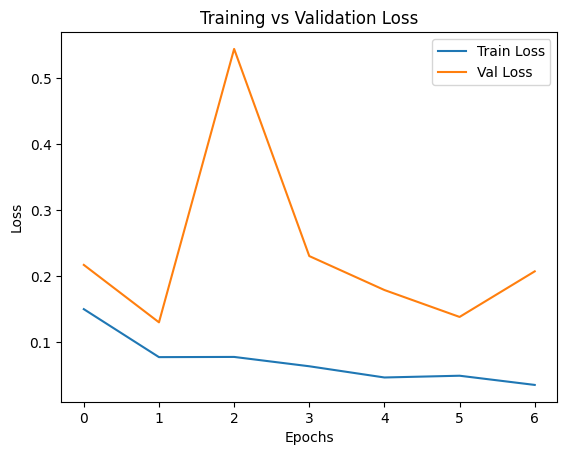

Demo risk prob = 0.971, true label = 1


In [ ]:
import os
# ============================
# CONFIG
# ============================
DATA_DIR = "/content/drive/MyDrive/Store/L2Heuristic_labels"  # where *_heuristic.npz live
MODEL_DIR = "/content/drive/MyDrive/Store/models/L2Models"
os.makedirs(MODEL_DIR, exist_ok=True)
WINDOW = 32      # frames per sample
STRIDE = 8      # hop between windows
BATCH_SIZE = 8
EPOCHS = 12
VAL_SPLIT = 0.2
SEED = 42

import glob, json, random, collections
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout, Concatenate,
                                     ConvLSTM2D, BatchNormalization,
                                     GlobalAveragePooling2D)
from tensorflow.keras.models import Model
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# ============================
# 1) LOAD & WINDOW THE DATA
# ============================
def load_npz_list(data_dir):
    return sorted(glob.glob(os.path.join(data_dir, "*_heuristic.npz")))

def make_windows(features, heatmaps, labels, window=64, stride=16, label_mode="majority"):
    """
    features: (T, 6)
    heatmaps: (T, 16, 16)
    labels:   (T,)
    Returns lists of windowed samples.
    label_mode: 'max' (risk if any risky frame in window)
                'last' (last frame label)
                'majority' (more than half risky → 1)
    """
    T = len(labels)
    Xf_list, Xh_list, y_list = [], [], []
    for start in range(0, max(T - window + 1, 0), stride):
        end = start + window
        xf = features[start:end]                # (W, 6)
        xh = heatmaps[start:end][..., None]     # (W, 16,16,1)
        yl = labels[start:end]                  # (W,)

        if len(xf) < window:
            continue

        if label_mode == "max":
            y = int(yl.max())
        elif label_mode == "last":
            y = int(yl[-1])
        else:  # majority
            y = int((yl.sum() >= (len(yl) / 2)))

        Xf_list.append(xf.astype(np.float32))
        Xh_list.append(xh.astype(np.float32))
        y_list.append(y)

    return Xf_list, Xh_list, y_list

all_files = load_npz_list(DATA_DIR)
print(f"Found {len(all_files)} sequences.")

Xf_all, Xh_all, y_all = [], [], []
for fp in all_files:
    d = np.load(fp)
    features = d["features"]            # (T, 6)
    heatmaps = d["heatmaps"]            # (T, 16, 16)
    labels   = d["labels"]              # (T,)
    xf, xh, y = make_windows(features, heatmaps, labels,
                             window=WINDOW, stride=STRIDE, label_mode="majority")
    Xf_all.extend(xf)
    Xh_all.extend(xh)
    y_all.extend(y)

Xf_all = np.stack(Xf_all)            # (N, W, 6)
Xh_all = np.stack(Xh_all)            # (N, W, 16, 16, 1)
y_all  = np.array(y_all, np.int64)   # (N,)
print("Windowed shapes:", Xf_all.shape, Xh_all.shape, y_all.shape)

# ============================
# 2) NORMALIZE FEATURES
# ============================
Xf_train_raw, Xf_val_raw, Xh_train, Xh_val, y_train, y_val = train_test_split(
    Xf_all, Xh_all, y_all, test_size=VAL_SPLIT, random_state=SEED, stratify=y_all
)

print("Full dataset label balance:", collections.Counter(y_all))
print("Train split balance:", collections.Counter(y_train))
print("Val split balance:", collections.Counter(y_val))

feat_mean = Xf_train_raw.reshape(-1, Xf_train_raw.shape[-1]).mean(axis=0)
feat_std  = Xf_train_raw.reshape(-1, Xf_train_raw.shape[-1]).std(axis=0) + 1e-6

def norm_feats(x): return (x - feat_mean) / feat_std

Xf_train = norm_feats(Xf_train_raw)
Xf_val   = norm_feats(Xf_val_raw)

norm_path = os.path.join(DATA_DIR, "feature_norm.json")
with open(norm_path, "w") as f:
    json.dump({"mean": feat_mean.tolist(), "std": feat_std.tolist()}, f)
print("Saved normalization stats ->", norm_path)

# ============================
# 3) CLASS WEIGHTS
# ============================
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}
print("Class weights:", class_weight_dict)

# ============================
# 4) BUILD MODEL
# ============================
def build_model(window=WINDOW):
    in_feat = Input(shape=(window, 6), name="features")
    fx = LSTM(64, return_sequences=False)(in_feat)
    fx = Dense(64, activation="relu")(fx)

    in_heat = Input(shape=(window, 16, 16, 1), name="heatmaps")
    hx = ConvLSTM2D(32, (3,3), padding="same", return_sequences=True)(in_heat)
    hx = BatchNormalization()(hx)
    hx = ConvLSTM2D(64, (3,3), padding="same", return_sequences=False)(hx)
    hx = BatchNormalization()(hx)
    hx = GlobalAveragePooling2D()(hx)

    z = Concatenate()([fx, hx])
    z = Dense(128, activation="relu")(z)
    z = Dropout(0.3)(z)
    out = Dense(1, activation="sigmoid")(z)

    model = Model(inputs=[in_feat, in_heat], outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=[tf.keras.metrics.AUC(name="auc"),
                           tf.keras.metrics.Precision(name="precision"),
                           tf.keras.metrics.Recall(name="recall"),
                           "accuracy"])
    return model

model = build_model(WINDOW)
model.summary()

# ============================
# 5) TRAIN
# ============================
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(MODEL_DIR, "dual_branch_best.keras"),
        monitor="val_auc", mode="max", save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=5, restore_best_weights=True, verbose=1)
]

history = model.fit(
    {"features": Xf_train, "heatmaps": Xh_train}, y_train,
    validation_data=({"features": Xf_val, "heatmaps": Xh_val}, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

final_path = os.path.join(MODEL_DIR, "dual_branch_final.keras")
model.save(final_path)
print("Saved model ->", final_path)

# ============================
# 6) EVALUATION
# ============================
y_pred_probs = model.predict({"features": Xf_val, "heatmaps": Xh_val})
y_pred = (y_pred_probs > 0.5).astype(int)

print("\nClassification Report:\n", classification_report(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Training curves
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

# ============================
# 7) SIMPLE INFERENCE HELPER
# ============================
def predict_sequence(features_window, heatmaps_window, model, mean, std):
    f = (features_window - mean) / (std + 1e-6)
    f = np.expand_dims(f.astype(np.float32), 0)
    h = np.expand_dims(heatmaps_window.astype(np.float32), 0)
    prob = model.predict({"features": f, "heatmaps": h}, verbose=0)[0,0]
    return float(prob)

idx = np.random.randint(0, Xf_val.shape[0])
demo_prob = predict_sequence(Xf_val_raw[idx], Xh_val[idx], model, feat_mean, feat_std)
print(f"Demo risk prob = {demo_prob:.3f}, true label = {y_val[idx]}")


# k-fold cross validation

In [ ]:
import os
# ============================
# CONFIG
# ============================
DATA_DIR = "/content/drive/MyDrive/Store/L2Heuristic_labels"  # where *_heuristic.npz live
MODEL_DIR = "/content/drive/MyDrive/Store/models/model_w_kfold"
os.makedirs(MODEL_DIR, exist_ok=True)
WINDOW = 32      # frames per sample
STRIDE = 8       # hop between windows
BATCH_SIZE = 8
EPOCHS = 12
N_SPLITS = 5     # K-Fold
SEED = 42

import glob, json, random, collections
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout, Concatenate,
                                     ConvLSTM2D, BatchNormalization,
                                     GlobalAveragePooling2D)
from tensorflow.keras.models import Model
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# ============================
# 1) LOAD & WINDOW THE DATA
# ============================
def load_npz_list(data_dir):
    return sorted(glob.glob(os.path.join(data_dir, "*_heuristic.npz")))

def make_windows(features, heatmaps, labels, window=64, stride=16, label_mode="majority"):
    T = len(labels)
    Xf_list, Xh_list, y_list = [], [], []
    for start in range(0, max(T - window + 1, 0), stride):
        end = start + window
        xf = features[start:end]                # (W, 6)
        xh = heatmaps[start:end][..., None]     # (W, 16,16,1)
        yl = labels[start:end]                  # (W,)
        if len(xf) < window:
            continue

        if label_mode == "max":
            y = int(yl.max())
        elif label_mode == "last":
            y = int(yl[-1])
        else:  # majority
            y = int((yl.sum() >= (len(yl) / 2)))

        Xf_list.append(xf.astype(np.float32))
        Xh_list.append(xh.astype(np.float32))
        y_list.append(y)
    return Xf_list, Xh_list, y_list

all_files = load_npz_list(DATA_DIR)
print(f"Found {len(all_files)} sequences.")

Xf_all, Xh_all, y_all = [], [], []
for fp in all_files:
    d = np.load(fp)
    features = d["features"]            # (T, 6)
    heatmaps = d["heatmaps"]            # (T, 16, 16)
    labels   = d["labels"]              # (T,)
    xf, xh, y = make_windows(features, heatmaps, labels,
                             window=WINDOW, stride=STRIDE, label_mode="majority")
    Xf_all.extend(xf)
    Xh_all.extend(xh)
    y_all.extend(y)

Xf_all = np.stack(Xf_all)            # (N, W, 6)
Xh_all = np.stack(Xh_all)            # (N, W, 16, 16, 1)
y_all  = np.array(y_all, np.int64)   # (N,)
print("Windowed shapes:", Xf_all.shape, Xh_all.shape, y_all.shape)
print("Full dataset label balance:", collections.Counter(y_all))

# ============================
# 2) BUILD MODEL FUNCTION
# ============================
def build_model(window=WINDOW):
    in_feat = Input(shape=(window, 6), name="features")
    fx = LSTM(64, return_sequences=False)(in_feat)
    fx = Dense(64, activation="relu")(fx)

    in_heat = Input(shape=(window, 16, 16, 1), name="heatmaps")
    hx = ConvLSTM2D(32, (3,3), padding="same", return_sequences=True)(in_heat)
    hx = BatchNormalization()(hx)
    hx = ConvLSTM2D(64, (3,3), padding="same", return_sequences=False)(hx)
    hx = BatchNormalization()(hx)
    hx = GlobalAveragePooling2D()(hx)

    z = Concatenate()([fx, hx])
    z = Dense(128, activation="relu")(z)
    z = Dropout(0.3)(z)
    out = Dense(1, activation="sigmoid")(z)

    model = Model(inputs=[in_feat, in_heat], outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=[tf.keras.metrics.AUC(name="auc"),
                           tf.keras.metrics.Precision(name="precision"),
                           tf.keras.metrics.Recall(name="recall"),
                           "accuracy"])
    return model

# ============================
# 3) K-FOLD CROSS VALIDATION
# ============================
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

histories = []
reports = []

for fold, (train_idx, val_idx) in enumerate(skf.split(Xf_all, y_all), 1):
    print(f"\n===== Fold {fold}/{N_SPLITS} =====")

    Xf_train_raw, Xf_val_raw = Xf_all[train_idx], Xf_all[val_idx]
    Xh_train, Xh_val = Xh_all[train_idx], Xh_all[val_idx]
    y_train, y_val = y_all[train_idx], y_all[val_idx]

    # Normalize per fold
    feat_mean = Xf_train_raw.reshape(-1, Xf_train_raw.shape[-1]).mean(axis=0)
    feat_std  = Xf_train_raw.reshape(-1, Xf_train_raw.shape[-1]).std(axis=0) + 1e-6
    def norm_feats(x): return (x - feat_mean) / feat_std
    Xf_train = norm_feats(Xf_train_raw)
    Xf_val   = norm_feats(Xf_val_raw)

    # Class weights
    classes = np.unique(y_train)
    class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}
    print("Train split balance:", collections.Counter(y_train))
    print("Val split balance:", collections.Counter(y_val))
    print("Class weights:", class_weight_dict)

    # Build model
    model = build_model(WINDOW)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max", patience=3, restore_best_weights=True, verbose=1)
    ]

    history = model.fit(
        {"features": Xf_train, "heatmaps": Xh_train}, y_train,
        validation_data=({"features": Xf_val, "heatmaps": Xh_val}, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=1
    )
    histories.append(history.history)

    # Evaluate
    y_pred_probs = model.predict({"features": Xf_val, "heatmaps": Xh_val})
    y_pred = (y_pred_probs > 0.5).astype(int)

    print("\nClassification Report (Fold {}):\n".format(fold),
          classification_report(y_val, y_pred))

    reports.append(classification_report(y_val, y_pred, output_dict=True))

    # Optional: save fold model
    model.save(os.path.join(MODEL_DIR, f"dual_branch_fold{fold}.keras"))



Found 4 sequences.
Windowed shapes: (1106, 32, 6) (1106, 32, 16, 16, 1) (1106,)
Full dataset label balance: Counter({np.int64(1): 685, np.int64(0): 421})

===== Fold 1/5 =====
Train split balance: Counter({np.int64(1): 548, np.int64(0): 336})
Val split balance: Counter({np.int64(1): 137, np.int64(0): 85})
Class weights: {0: 1.3154761904761905, 1: 0.8065693430656934}
Epoch 1/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 33s 233ms/step - accuracy: 0.9138 - auc: 0.9790 - loss: 0.2232 - precision: 0.9836 - recall: 0.8767 - val_accuracy: 0.9640 - val_auc: 0.9835 - val_loss: 0.1266 - val_precision: 0.9850 - val_recall: 0.9562
Epoch 2/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 24s 220ms/step - accuracy: 0.9648 - auc: 0.9897 - loss: 0.1016 - precision: 0.9898 - recall: 0.9539 - val_accuracy: 0.9369 - val_auc: 0.9970 - val_loss: 0.1641 - val_precision: 1.0000 - val_recall: 0.8978
Epoch 3/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 43s 239ms/step - accuracy: 0.9658 - auc: 0.9896 - loss: 0.0969 - precision: 0.9908 - recall: 0.9547 -

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 177ms/step

Classification Report (Fold 2):
               precision    recall  f1-score   support

           0       0.89      1.00      0.94        84
           1       1.00      0.93      0.96       137

    accuracy                           0.95       221
   macro avg       0.95      0.96      0.95       221
weighted avg       0.96      0.95      0.96       221


===== Fold 3/5 =====
Train split balance: Counter({np.int64(1): 548, np.int64(0): 337})
Val split balance: Counter({np.int64(1): 137, np.int64(0): 84})
Class weights: {0: 1.3130563798219586, 1: 0.8074817518248175}
Epoch 1/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 32s 242ms/step - accuracy: 0.9125 - auc: 0.9679 - loss: 0.2462 - precision: 0.9776 - recall: 0.8825 - val_accuracy: 0.9321 - val_auc: 0.9659 - val_loss: 0.2260 - val_precision: 0.9692 - val_recall: 0.9197
Epoch 2/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 25s 221ms/step - accuracy: 0.9658 - auc: 0.9913 - loss: 0.0970 - precision: 0.9863 - recall: 0.9593 

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 162ms/step

Classification Report (Fold 3):
               precision    recall  f1-score   support

           0       0.90      0.98      0.94        84
           1       0.98      0.93      0.96       137

    accuracy                           0.95       221
   macro avg       0.94      0.96      0.95       221
weighted avg       0.95      0.95      0.95       221


===== Fold 4/5 =====
Train split balance: Counter({np.int64(1): 548, np.int64(0): 337})
Val split balance: Counter({np.int64(1): 137, np.int64(0): 84})
Class weights: {0: 1.3130563798219586, 1: 0.8074817518248175}
Epoch 1/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 33s 235ms/step - accuracy: 0.8557 - auc: 0.9500 - loss: 0.2756 - precision: 0.9488 - recall: 0.8089 - val_accuracy: 0.9638 - val_auc: 0.9921 - val_loss: 0.1572 - val_precision: 1.0000 - val_recall: 0.9416
Epoch 2/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 42s 242ms/step - accuracy: 0.9597 - auc: 0.9874 - loss: 0.1281 - precision: 0.9807 - recall: 0.9545 

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (5,) + inhomogeneous part.

## with visualization per fold

Found 4 sequences.
Windowed shapes: (1106, 32, 6) (1106, 32, 16, 16, 1) (1106,)
Full dataset label balance: Counter({np.int64(1): 685, np.int64(0): 421})

===== Fold 1/5 =====
Train split balance: Counter({np.int64(1): 548, np.int64(0): 336})
Val split balance: Counter({np.int64(1): 137, np.int64(0): 85})
Class weights: {0: 1.3154761904761905, 1: 0.8065693430656934}
Epoch 1/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 39s 244ms/step - accuracy: 0.9138 - auc: 0.9790 - loss: 0.2232 - precision: 0.9836 - recall: 0.8767 - val_accuracy: 0.9640 - val_auc: 0.9835 - val_loss: 0.1266 - val_precision: 0.9850 - val_recall: 0.9562
Epoch 2/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 31s 219ms/step - accuracy: 0.9648 - auc: 0.9898 - loss: 0.1014 - precision: 0.9898 - recall: 0.9539 - val_accuracy: 0.9369 - val_auc: 0.9974 - val_loss: 0.1526 - val_precision: 1.0000 - val_recall: 0.8978
Epoch 3/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 26s 234ms/step - accuracy: 0.9657 - auc: 0.9903 - loss: 0.0981 - precision: 0.9919 - recall: 0.9533 -

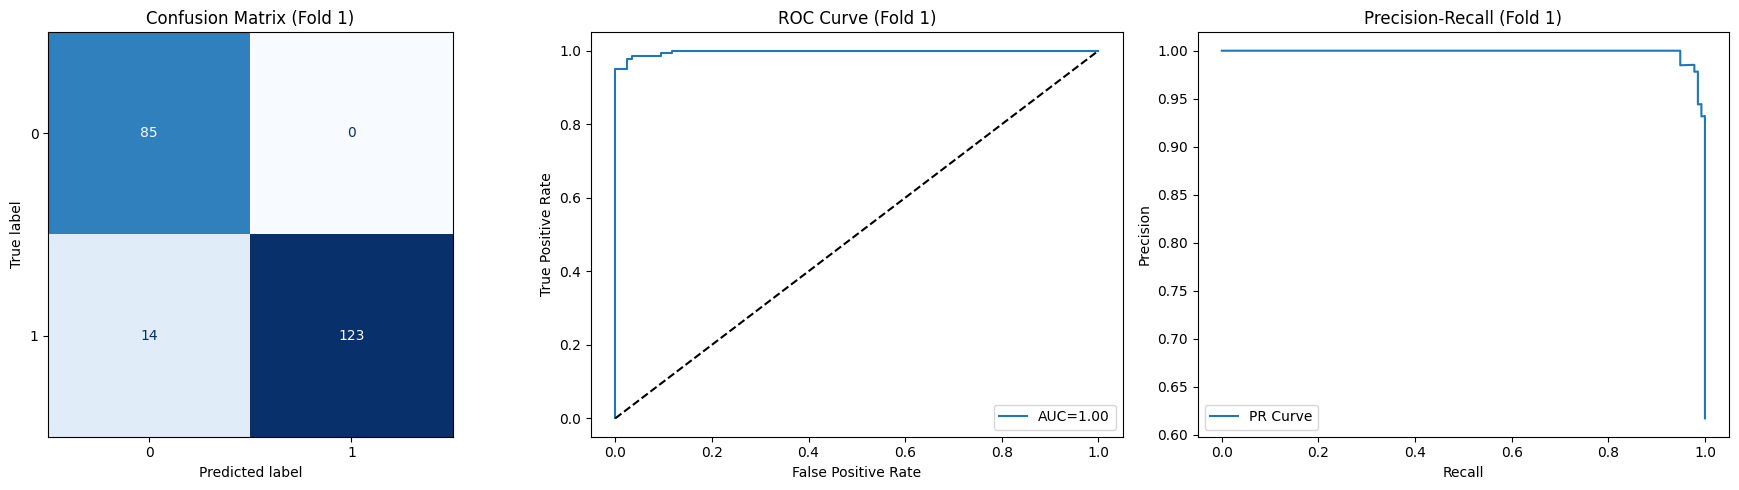


===== Fold 2/5 =====
Train split balance: Counter({np.int64(1): 548, np.int64(0): 337})
Val split balance: Counter({np.int64(1): 137, np.int64(0): 84})
Class weights: {0: 1.3130563798219586, 1: 0.8074817518248175}
Epoch 1/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 32s 241ms/step - accuracy: 0.8874 - auc: 0.9621 - loss: 0.2381 - precision: 0.9650 - recall: 0.8509 - val_accuracy: 0.9774 - val_auc: 0.9977 - val_loss: 0.0886 - val_precision: 1.0000 - val_recall: 0.9635
Epoch 2/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 39s 229ms/step - accuracy: 0.9693 - auc: 0.9955 - loss: 0.0758 - precision: 0.9954 - recall: 0.9556 - val_accuracy: 0.9819 - val_auc: 0.9980 - val_loss: 0.0622 - val_precision: 1.0000 - val_recall: 0.9708
Epoch 3/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 39s 213ms/step - accuracy: 0.9742 - auc: 0.9976 - loss: 0.0578 - precision: 0.9947 - recall: 0.9642 - val_accuracy: 0.9593 - val_auc: 0.9981 - val_loss: 0.0996 - val_precision: 0.9384 - val_recall: 1.0000
Epoch 4/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 41s 216ms/

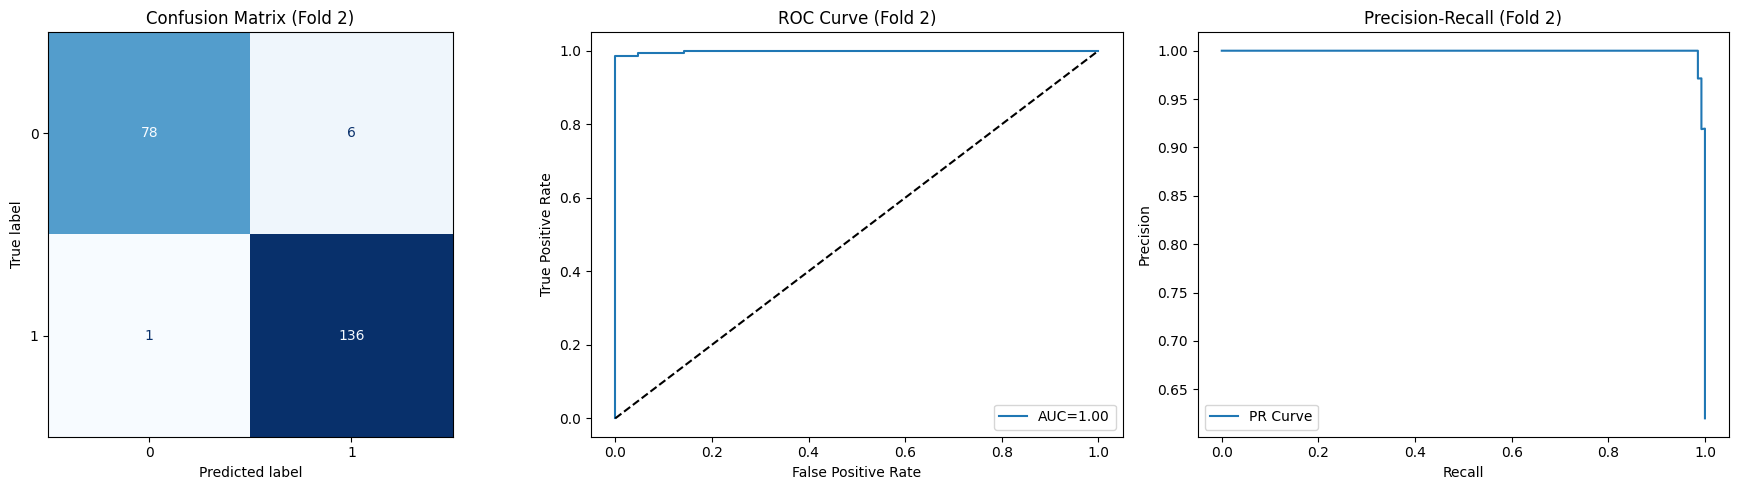


===== Fold 3/5 =====
Train split balance: Counter({np.int64(1): 548, np.int64(0): 337})
Val split balance: Counter({np.int64(1): 137, np.int64(0): 84})
Class weights: {0: 1.3130563798219586, 1: 0.8074817518248175}
Epoch 1/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 32s 223ms/step - accuracy: 0.9125 - auc: 0.9679 - loss: 0.2462 - precision: 0.9776 - recall: 0.8825 - val_accuracy: 0.9321 - val_auc: 0.9712 - val_loss: 0.2263 - val_precision: 0.9692 - val_recall: 0.9197
Epoch 2/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 23s 202ms/step - accuracy: 0.9685 - auc: 0.9913 - loss: 0.0951 - precision: 0.9879 - recall: 0.9619 - val_accuracy: 0.9367 - val_auc: 0.9778 - val_loss: 0.3166 - val_precision: 0.9843 - val_recall: 0.9124
Epoch 3/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 43s 226ms/step - accuracy: 0.9651 - auc: 0.9952 - loss: 0.0777 - precision: 0.9793 - recall: 0.9651 - val_accuracy: 0.9321 - val_auc: 0.9782 - val_loss: 0.3215 - val_precision: 0.9919 - val_recall: 0.8978
Epoch 4/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 47s 280ms/

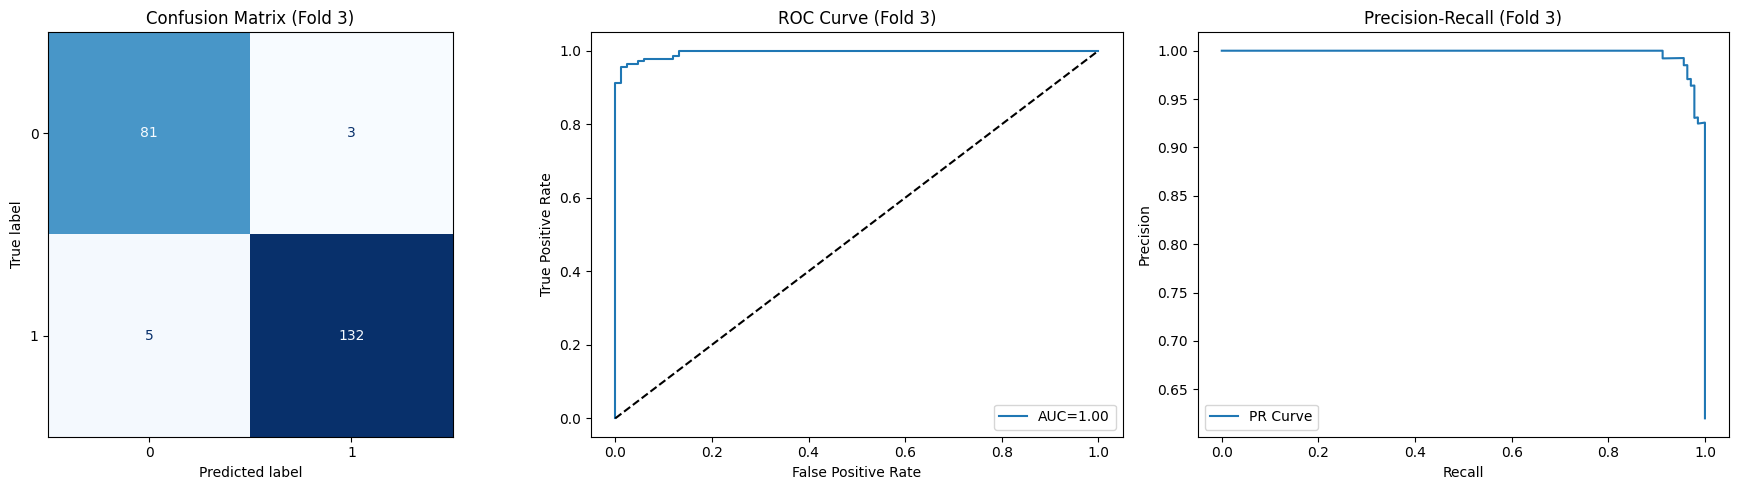


===== Fold 4/5 =====
Train split balance: Counter({np.int64(1): 548, np.int64(0): 337})
Val split balance: Counter({np.int64(1): 137, np.int64(0): 84})
Class weights: {0: 1.3130563798219586, 1: 0.8074817518248175}
Epoch 1/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 31s 229ms/step - accuracy: 0.8558 - auc: 0.9500 - loss: 0.2755 - precision: 0.9491 - recall: 0.8088 - val_accuracy: 0.9638 - val_auc: 0.9921 - val_loss: 0.1497 - val_precision: 1.0000 - val_recall: 0.9416
Epoch 2/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 24s 219ms/step - accuracy: 0.9622 - auc: 0.9896 - loss: 0.1156 - precision: 0.9829 - recall: 0.9562 - val_accuracy: 0.9729 - val_auc: 0.9987 - val_loss: 0.0698 - val_precision: 1.0000 - val_recall: 0.9562
Epoch 3/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 41s 219ms/step - accuracy: 0.9624 - auc: 0.9954 - loss: 0.0822 - precision: 0.9847 - recall: 0.9548 - val_accuracy: 0.9729 - val_auc: 0.9984 - val_loss: 0.0670 - val_precision: 1.0000 - val_recall: 0.9562
Epoch 4/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 41s 215ms/

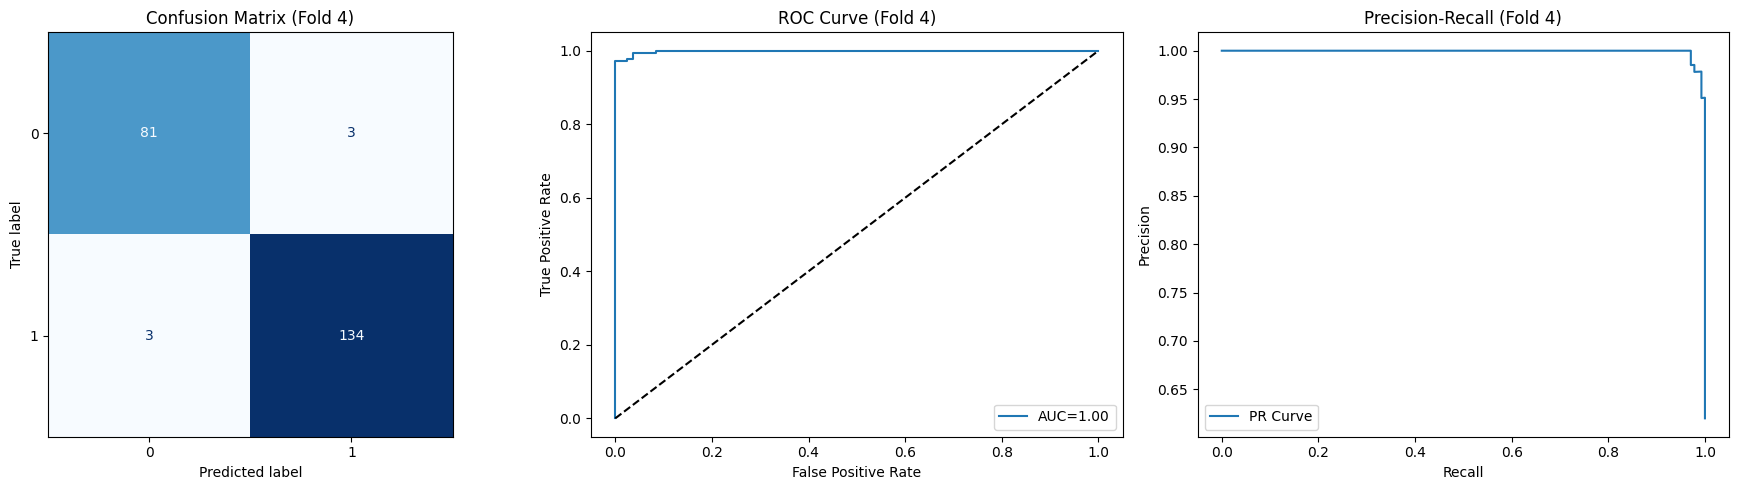


===== Fold 5/5 =====
Train split balance: Counter({np.int64(1): 548, np.int64(0): 337})
Val split balance: Counter({np.int64(1): 137, np.int64(0): 84})
Class weights: {0: 1.3130563798219586, 1: 0.8074817518248175}
Epoch 1/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 33s 235ms/step - accuracy: 0.8873 - auc: 0.9646 - loss: 0.2538 - precision: 0.9738 - recall: 0.8437 - val_accuracy: 0.9412 - val_auc: 0.9831 - val_loss: 0.2643 - val_precision: 0.9921 - val_recall: 0.9124
Epoch 2/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 40s 223ms/step - accuracy: 0.9734 - auc: 0.9926 - loss: 0.0764 - precision: 0.9935 - recall: 0.9639 - val_accuracy: 0.9140 - val_auc: 0.9833 - val_loss: 0.4492 - val_precision: 1.0000 - val_recall: 0.8613
Epoch 3/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 25s 229ms/step - accuracy: 0.9693 - auc: 0.9955 - loss: 0.0736 - precision: 0.9919 - recall: 0.9590 - val_accuracy: 0.8190 - val_auc: 0.9876 - val_loss: 0.5805 - val_precision: 1.0000 - val_recall: 0.7080
Epoch 4/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 41s 226ms/

In [ ]:
import os
# ============================
# CONFIG
# ============================
DATA_DIR = "/content/drive/MyDrive/Store/L2Heuristic_labels"  # where *_heuristic.npz live
MODEL_DIR = "/content/drive/MyDrive/Store/models/model_w_kfold2"
os.makedirs(MODEL_DIR, exist_ok=True)
WINDOW = 32      # frames per sample
STRIDE = 8       # hop between windows
BATCH_SIZE = 8
EPOCHS = 12
N_SPLITS = 5     # K-Fold
SEED = 42

import glob, json, random, collections
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout, Concatenate,
                                     ConvLSTM2D, BatchNormalization,
                                     GlobalAveragePooling2D)
from tensorflow.keras.models import Model
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# ============================
# 1) LOAD & WINDOW THE DATA
# ============================
def load_npz_list(data_dir):
    return sorted(glob.glob(os.path.join(data_dir, "*_heuristic.npz")))

def make_windows(features, heatmaps, labels, window=64, stride=16, label_mode="majority"):
    T = len(labels)
    Xf_list, Xh_list, y_list = [], [], []
    for start in range(0, max(T - window + 1, 0), stride):
        end = start + window
        xf = features[start:end]                # (W, 6)
        xh = heatmaps[start:end][..., None]     # (W, 16,16,1)
        yl = labels[start:end]                  # (W,)
        if len(xf) < window:
            continue

        if label_mode == "max":
            y = int(yl.max())
        elif label_mode == "last":
            y = int(yl[-1])
        else:  # majority
            y = int((yl.sum() >= (len(yl) / 2)))

        Xf_list.append(xf.astype(np.float32))
        Xh_list.append(xh.astype(np.float32))
        y_list.append(y)
    return Xf_list, Xh_list, y_list

all_files = load_npz_list(DATA_DIR)
print(f"Found {len(all_files)} sequences.")

Xf_all, Xh_all, y_all = [], [], []
for fp in all_files:
    d = np.load(fp)
    features = d["features"]            # (T, 6)
    heatmaps = d["heatmaps"]            # (T, 16, 16)
    labels   = d["labels"]              # (T,)
    xf, xh, y = make_windows(features, heatmaps, labels,
                             window=WINDOW, stride=STRIDE, label_mode="majority")
    Xf_all.extend(xf)
    Xh_all.extend(xh)
    y_all.extend(y)

Xf_all = np.stack(Xf_all)            # (N, W, 6)
Xh_all = np.stack(Xh_all)            # (N, W, 16, 16, 1)
y_all  = np.array(y_all, np.int64)   # (N,)
print("Windowed shapes:", Xf_all.shape, Xh_all.shape, y_all.shape)
print("Full dataset label balance:", collections.Counter(y_all))

# ============================
# 2) BUILD MODEL FUNCTION
# ============================
def build_model(window=WINDOW):
    in_feat = Input(shape=(window, 6), name="features")
    fx = LSTM(64, return_sequences=False)(in_feat)
    fx = Dense(64, activation="relu")(fx)

    in_heat = Input(shape=(window, 16, 16, 1), name="heatmaps")
    hx = ConvLSTM2D(32, (3,3), padding="same", return_sequences=True)(in_heat)
    hx = BatchNormalization()(hx)
    hx = ConvLSTM2D(64, (3,3), padding="same", return_sequences=False)(hx)
    hx = BatchNormalization()(hx)
    hx = GlobalAveragePooling2D()(hx)

    z = Concatenate()([fx, hx])
    z = Dense(128, activation="relu")(z)
    z = Dropout(0.3)(z)
    out = Dense(1, activation="sigmoid")(z)

    model = Model(inputs=[in_feat, in_heat], outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=[tf.keras.metrics.AUC(name="auc"),
                           tf.keras.metrics.Precision(name="precision"),
                           tf.keras.metrics.Recall(name="recall"),
                           "accuracy"])
    return model

# ============================
# 3) K-FOLD CROSS VALIDATION
# ============================
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

histories = []
reports = []

for fold, (train_idx, val_idx) in enumerate(skf.split(Xf_all, y_all), 1):
    print(f"\n===== Fold {fold}/{N_SPLITS} =====")

    Xf_train_raw, Xf_val_raw = Xf_all[train_idx], Xf_all[val_idx]
    Xh_train, Xh_val = Xh_all[train_idx], Xh_all[val_idx]
    y_train, y_val = y_all[train_idx], y_all[val_idx]

    # Normalize per fold
    feat_mean = Xf_train_raw.reshape(-1, Xf_train_raw.shape[-1]).mean(axis=0)
    feat_std  = Xf_train_raw.reshape(-1, Xf_train_raw.shape[-1]).std(axis=0) + 1e-6
    def norm_feats(x): return (x - feat_mean) / feat_std
    Xf_train = norm_feats(Xf_train_raw)
    Xf_val   = norm_feats(Xf_val_raw)

    # Class weights
    classes = np.unique(y_train)
    class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}
    print("Train split balance:", collections.Counter(y_train))
    print("Val split balance:", collections.Counter(y_val))
    print("Class weights:", class_weight_dict)

    # Build model
    model = build_model(WINDOW)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max", patience=3, restore_best_weights=True, verbose=1)
    ]

    history = model.fit(
        {"features": Xf_train, "heatmaps": Xh_train}, y_train,
        validation_data=({"features": Xf_val, "heatmaps": Xh_val}, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=1
    )
    histories.append(history.history)

    # Evaluate
    y_pred_probs = model.predict({"features": Xf_val, "heatmaps": Xh_val})
    y_pred = (y_pred_probs > 0.5).astype(int)

    print("\nClassification Report (Fold {}):\n".format(fold),
          classification_report(y_val, y_pred))

    reports.append(classification_report(y_val, y_pred, output_dict=True))

        # Evaluate
    y_pred_probs = model.predict({"features": Xf_val, "heatmaps": Xh_val})
    y_pred = (y_pred_probs > 0.5).astype(int)

    print("\nClassification Report (Fold {}):\n".format(fold),
          classification_report(y_val, y_pred))

    reports.append(classification_report(y_val, y_pred, output_dict=True))

    # ======================
    # VISUALIZATIONS
    # ======================
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))

    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax[0], cmap="Blues", colorbar=False)
    ax[0].set_title(f"Confusion Matrix (Fold {fold})")

    # ROC Curve
    from sklearn.metrics import roc_curve, auc, precision_recall_curve
    fpr, tpr, _ = roc_curve(y_val, y_pred_probs)
    roc_auc = auc(fpr, tpr)
    ax[1].plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
    ax[1].plot([0,1], [0,1], "k--")
    ax[1].set_xlabel("False Positive Rate")
    ax[1].set_ylabel("True Positive Rate")
    ax[1].set_title(f"ROC Curve (Fold {fold})")
    ax[1].legend(loc="lower right")

    # Precision-Recall Curve
    prec, rec, _ = precision_recall_curve(y_val, y_pred_probs)
    ax[2].plot(rec, prec, label="PR Curve")
    ax[2].set_xlabel("Recall")
    ax[2].set_ylabel("Precision")
    ax[2].set_title(f"Precision-Recall (Fold {fold})")
    ax[2].legend(loc="lower left")

    plt.tight_layout()
    plt.show()


    # Optional: save fold model
    model.save(os.path.join(MODEL_DIR, f"dual_branch_fold{fold}.keras"))



Found 4 sequences.
Windowed shapes: (1106, 32, 6) (1106, 32, 16, 16, 1) (1106,)
Full dataset label balance: Counter({np.int64(1): 685, np.int64(0): 421})

===== Fold 1/5 =====
Train split balance: Counter({np.int64(1): 548, np.int64(0): 336})
Val split balance: Counter({np.int64(1): 137, np.int64(0): 85})
Class weights: {0: 1.3154761904761905, 1: 0.8065693430656934}
Epoch 1/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 37s 276ms/step - accuracy: 0.9138 - auc: 0.9790 - loss: 0.2232 - precision: 0.9836 - recall: 0.8767 - val_accuracy: 0.9640 - val_auc: 0.9835 - val_loss: 0.1266 - val_precision: 0.9850 - val_recall: 0.9562
Epoch 2/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 39s 260ms/step - accuracy: 0.9648 - auc: 0.9897 - loss: 0.1016 - precision: 0.9898 - recall: 0.9539 - val_accuracy: 0.9369 - val_auc: 0.9975 - val_loss: 0.1667 - val_precision: 1.0000 - val_recall: 0.8978
Epoch 3/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 37s 225ms/step - accuracy: 0.9670 - auc: 0.9898 - loss: 0.0958 - precision: 0.9915 - recall: 0.9559 -

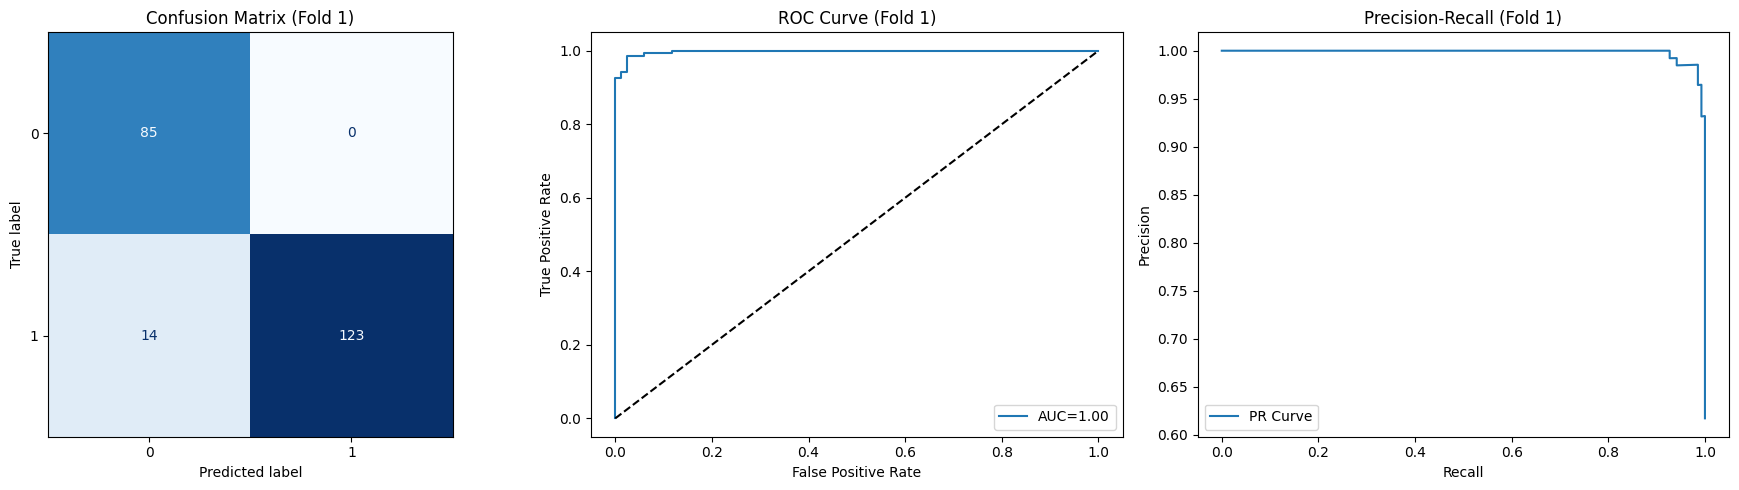


===== Fold 2/5 =====
Train split balance: Counter({np.int64(1): 548, np.int64(0): 337})
Val split balance: Counter({np.int64(1): 137, np.int64(0): 84})
Class weights: {0: 1.3130563798219586, 1: 0.8074817518248175}
Epoch 1/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 37s 269ms/step - accuracy: 0.8874 - auc: 0.9621 - loss: 0.2381 - precision: 0.9650 - recall: 0.8509 - val_accuracy: 0.9819 - val_auc: 0.9978 - val_loss: 0.0799 - val_precision: 1.0000 - val_recall: 0.9708
Epoch 2/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 28s 257ms/step - accuracy: 0.9692 - auc: 0.9961 - loss: 0.0748 - precision: 0.9947 - recall: 0.9561 - val_accuracy: 0.9683 - val_auc: 0.9980 - val_loss: 0.0829 - val_precision: 1.0000 - val_recall: 0.9489
Epoch 3/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 27s 247ms/step - accuracy: 0.9697 - auc: 0.9968 - loss: 0.0619 - precision: 0.9933 - recall: 0.9584 - val_accuracy: 0.9638 - val_auc: 0.9987 - val_loss: 0.0624 - val_precision: 0.9510 - val_recall: 0.9927
Epoch 4/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 41s 243ms/

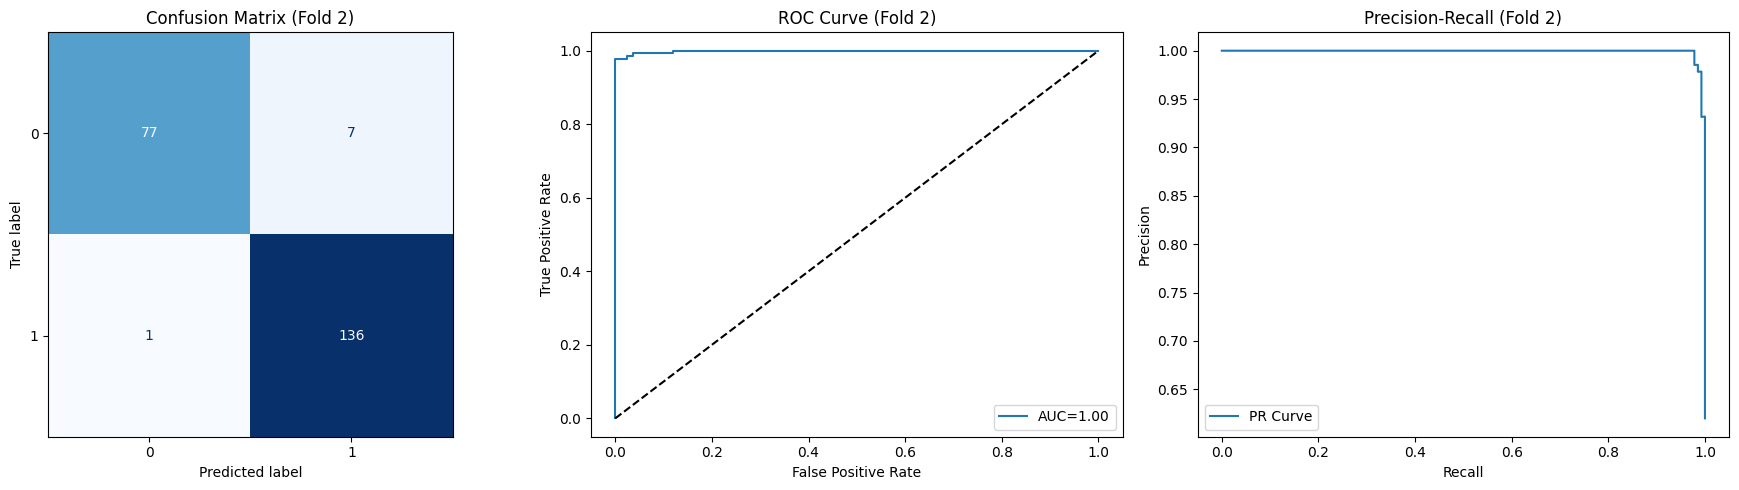


===== Fold 3/5 =====
Train split balance: Counter({np.int64(1): 548, np.int64(0): 337})
Val split balance: Counter({np.int64(1): 137, np.int64(0): 84})
Class weights: {0: 1.3130563798219586, 1: 0.8074817518248175}
Epoch 1/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 37s 271ms/step - accuracy: 0.9125 - auc: 0.9679 - loss: 0.2462 - precision: 0.9776 - recall: 0.8825 - val_accuracy: 0.9321 - val_auc: 0.9644 - val_loss: 0.2280 - val_precision: 0.9692 - val_recall: 0.9197
Epoch 2/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 40s 259ms/step - accuracy: 0.9689 - auc: 0.9913 - loss: 0.0927 - precision: 0.9879 - recall: 0.9626 - val_accuracy: 0.9593 - val_auc: 0.9918 - val_loss: 0.1299 - val_precision: 0.9923 - val_recall: 0.9416
Epoch 3/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 39s 239ms/step - accuracy: 0.9799 - auc: 0.9931 - loss: 0.0715 - precision: 0.9953 - recall: 0.9729 - val_accuracy: 0.9502 - val_auc: 0.9828 - val_loss: 0.1660 - val_precision: 0.9701 - val_recall: 0.9489
Epoch 4/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 43s 257ms/

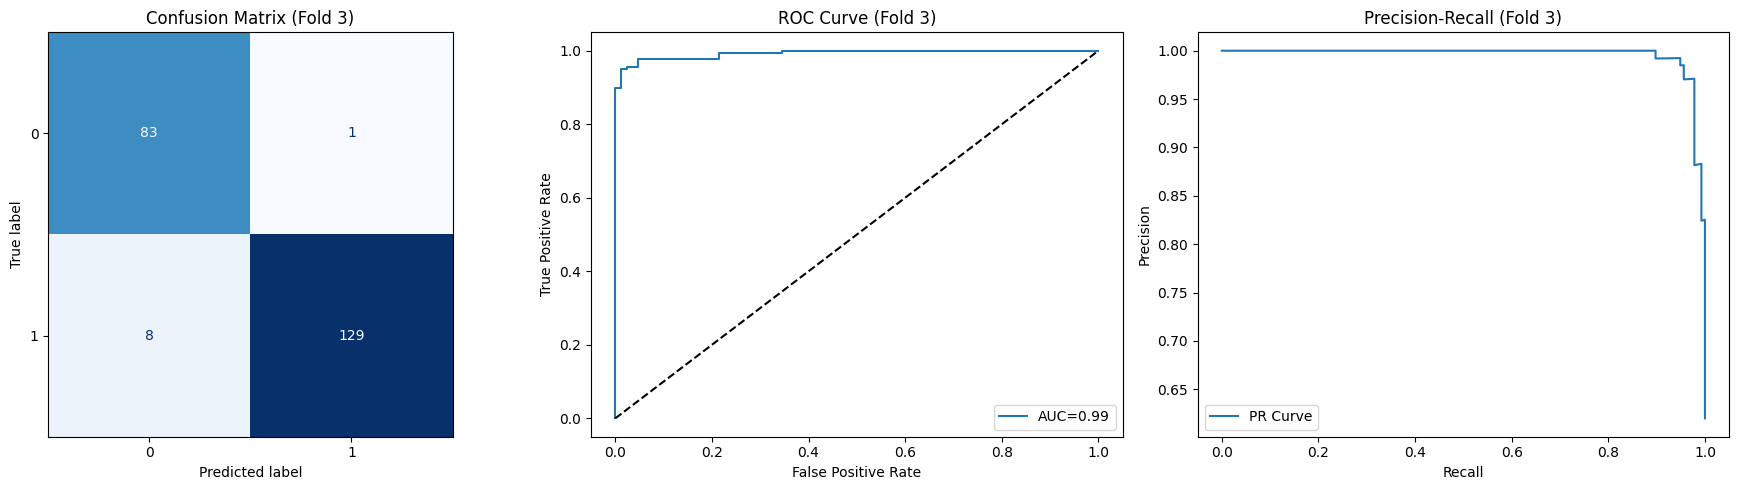


===== Fold 4/5 =====
Train split balance: Counter({np.int64(1): 548, np.int64(0): 337})
Val split balance: Counter({np.int64(1): 137, np.int64(0): 84})
Class weights: {0: 1.3130563798219586, 1: 0.8074817518248175}
Epoch 1/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 35s 264ms/step - accuracy: 0.8557 - auc: 0.9500 - loss: 0.2755 - precision: 0.9490 - recall: 0.8088 - val_accuracy: 0.9638 - val_auc: 0.9920 - val_loss: 0.1390 - val_precision: 1.0000 - val_recall: 0.9416
Epoch 2/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 37s 230ms/step - accuracy: 0.9619 - auc: 0.9916 - loss: 0.1068 - precision: 0.9864 - recall: 0.9522 - val_accuracy: 0.9774 - val_auc: 0.9992 - val_loss: 0.0464 - val_precision: 1.0000 - val_recall: 0.9635
Epoch 3/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 44s 255ms/step - accuracy: 0.9594 - auc: 0.9935 - loss: 0.0952 - precision: 0.9816 - recall: 0.9530 - val_accuracy: 0.9729 - val_auc: 0.9980 - val_loss: 0.0626 - val_precision: 0.9781 - val_recall: 0.9781
Epoch 4/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 26s 237ms/

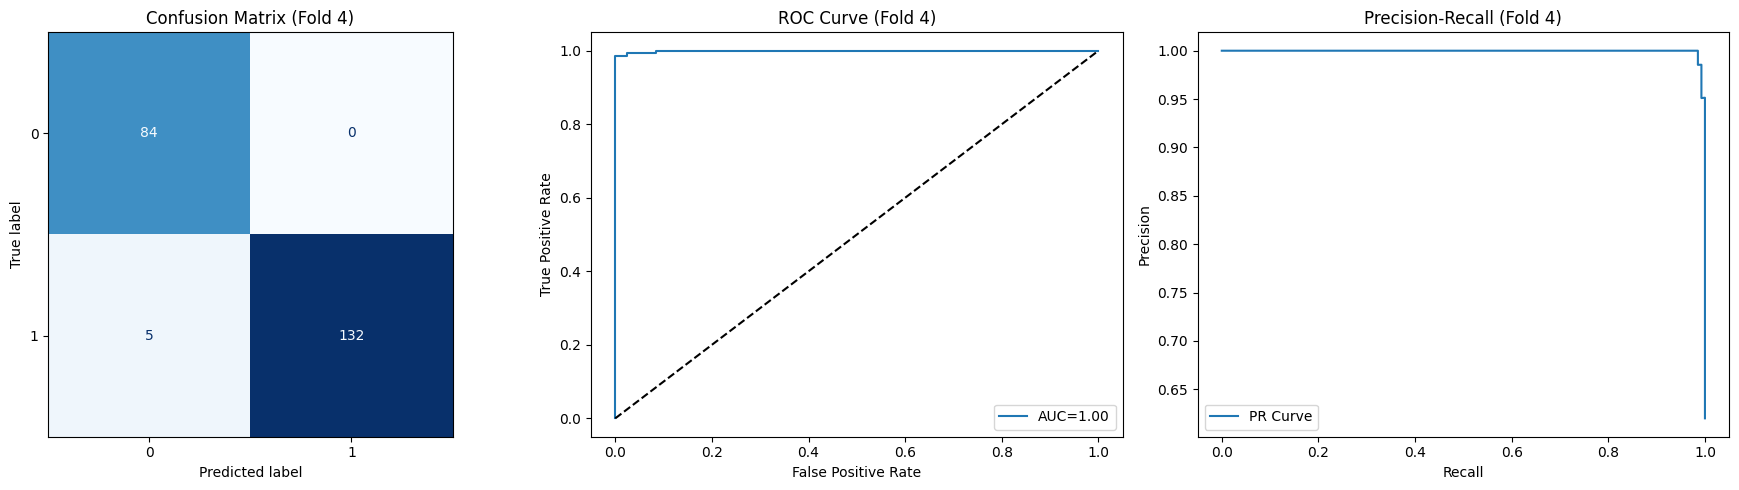


===== Fold 5/5 =====
Train split balance: Counter({np.int64(1): 548, np.int64(0): 337})
Val split balance: Counter({np.int64(1): 137, np.int64(0): 84})
Class weights: {0: 1.3130563798219586, 1: 0.8074817518248175}
Epoch 1/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 36s 258ms/step - accuracy: 0.8873 - auc: 0.9646 - loss: 0.2539 - precision: 0.9738 - recall: 0.8437 - val_accuracy: 0.9457 - val_auc: 0.9834 - val_loss: 0.2806 - val_precision: 1.0000 - val_recall: 0.9124
Epoch 2/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 28s 254ms/step - accuracy: 0.9750 - auc: 0.9925 - loss: 0.0762 - precision: 0.9936 - recall: 0.9664 - val_accuracy: 0.8824 - val_auc: 0.9801 - val_loss: 0.5700 - val_precision: 1.0000 - val_recall: 0.8102
Epoch 3/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 40s 241ms/step - accuracy: 0.9717 - auc: 0.9956 - loss: 0.0725 - precision: 0.9938 - recall: 0.9610 - val_accuracy: 0.9548 - val_auc: 0.9904 - val_loss: 0.1653 - val_precision: 0.9922 - val_recall: 0.9343
Epoch 4/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 27s 245ms/

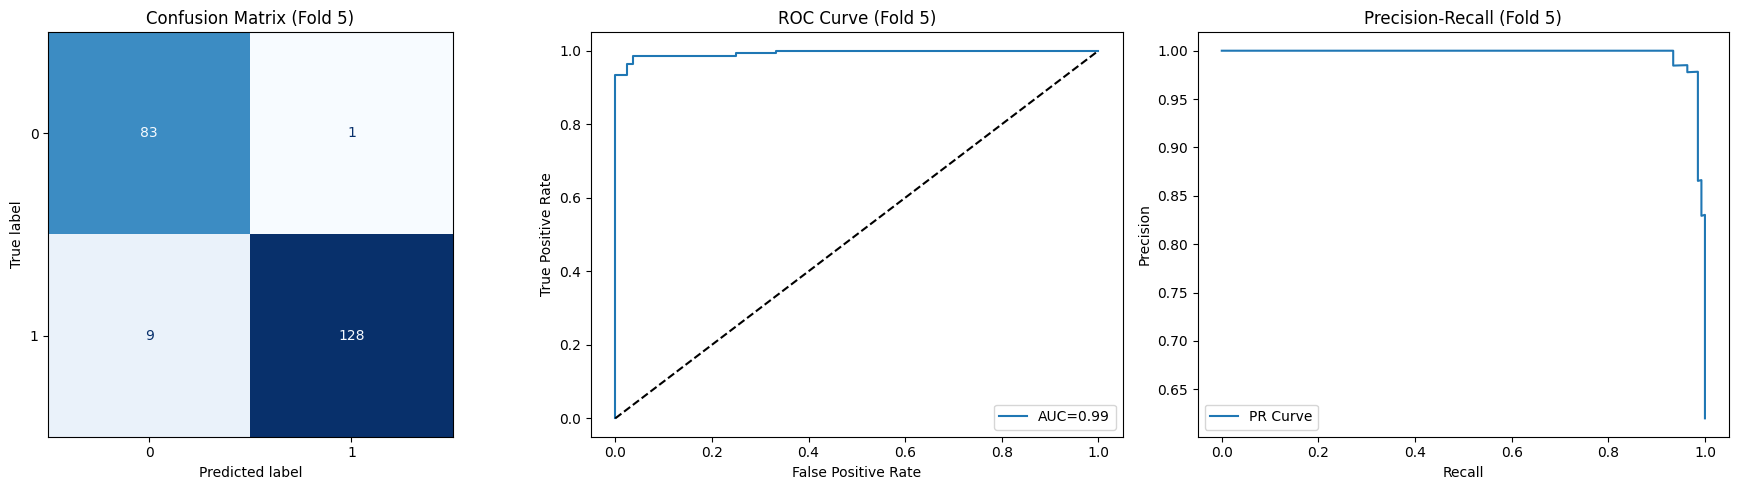

In [ ]:
!pip install tensorflow

import os
# ============================
# CONFIG
# ============================
DATA_DIR = "/content/drive/MyDrive/Store/L2Heuristic_labels"  # heuristic npz files
BYTE_DIR = "/content/drive/MyDrive/Store/L2ByteTrack"         # ByteTrack npy files
MODEL_DIR = "/content/drive/MyDrive/Store/models/model_w_kfold2"
os.makedirs(MODEL_DIR, exist_ok=True)
WINDOW = 32      # frames per sample
STRIDE = 8       # hop between windows
BATCH_SIZE = 8
EPOCHS = 12
N_SPLITS = 5     # K-Fold
SEED = 42

import glob, random, collections
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout, Concatenate,
                                     ConvLSTM2D, BatchNormalization,
                                     GlobalAveragePooling2D)
from tensorflow.keras.models import Model
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# ============================
# 1) LOAD & WINDOW THE DATA
# ============================
def load_npz_list(data_dir):
    return sorted(glob.glob(os.path.join(data_dir, "*_heuristic.npz")))

def load_bytetrack_features(npz_file, bytetrack_dir):
    base = os.path.basename(npz_file).replace("_heuristic.npz", "")
    bt_path = os.path.join(bytetrack_dir, base + "_bytetrack.npy")
    if os.path.exists(bt_path):
        bt_feats = np.load(bt_path)  # (T, K)
        return bt_feats
    else:
        return None

def make_windows(features, heatmaps, labels, window=64, stride=16, label_mode="majority"):
    T = len(labels)
    Xf_list, Xh_list, y_list = [], [], []
    for start in range(0, max(T - window + 1, 0), stride):
        end = start + window
        xf = features[start:end]                # (W, F)
        xh = heatmaps[start:end][..., None]     # (W, 16,16,1)
        yl = labels[start:end]                  # (W,)
        if len(xf) < window:
            continue

        if label_mode == "max":
            y = int(yl.max())
        elif label_mode == "last":
            y = int(yl[-1])
        else:  # majority
            y = int((yl.sum() >= (len(yl) / 2)))

        Xf_list.append(xf.astype(np.float32))
        Xh_list.append(xh.astype(np.float32))
        y_list.append(y)
    return Xf_list, Xh_list, y_list

all_files = load_npz_list(DATA_DIR)
print(f"Found {len(all_files)} sequences.")

Xf_all, Xh_all, y_all = [], [], []
for fp in all_files:
    d = np.load(fp)
    features = d["features"]            # (T, 6)
    heatmaps = d["heatmaps"]            # (T, 16, 16)
    labels   = d["labels"]              # (T,)

    # Merge with ByteTrack if available
    bt_feats = load_bytetrack_features(fp, BYTE_DIR)
    if bt_feats is not None and bt_feats.shape[0] == features.shape[0]:
        features = np.concatenate([features, bt_feats], axis=1)  # (T, 6+K)
    elif bt_feats is not None:
        print(f"[WARN] Mismatch in length for {fp}, skipping ByteTrack merge")

    xf, xh, y = make_windows(features, heatmaps, labels,
                             window=WINDOW, stride=STRIDE, label_mode="majority")
    Xf_all.extend(xf)
    Xh_all.extend(xh)
    y_all.extend(y)

Xf_all = np.stack(Xf_all)            # (N, W, 6+K)
Xh_all = np.stack(Xh_all)            # (N, W, 16, 16, 1)
y_all  = np.array(y_all, np.int64)   # (N,)
print("Windowed shapes:", Xf_all.shape, Xh_all.shape, y_all.shape)
print("Full dataset label balance:", collections.Counter(y_all))

# ============================
# 2) BUILD MODEL FUNCTION
# ============================
def build_model(window=WINDOW, n_features=None):
    if n_features is None:
        raise ValueError("n_features must be provided")

    in_feat = Input(shape=(window, n_features), name="features")
    fx = LSTM(64, return_sequences=False)(in_feat)
    fx = Dense(64, activation="relu")(fx)

    in_heat = Input(shape=(window, 16, 16, 1), name="heatmaps")
    hx = ConvLSTM2D(32, (3,3), padding="same", return_sequences=True)(in_heat)
    hx = BatchNormalization()(hx)
    hx = ConvLSTM2D(64, (3,3), padding="same", return_sequences=False)(hx)
    hx = BatchNormalization()(hx)
    hx = GlobalAveragePooling2D()(hx)

    z = Concatenate()([fx, hx])
    z = Dense(128, activation="relu")(z)
    z = Dropout(0.3)(z)
    out = Dense(1, activation="sigmoid")(z)

    model = Model(inputs=[in_feat, in_heat], outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=[tf.keras.metrics.AUC(name="auc"),
                           tf.keras.metrics.Precision(name="precision"),
                           tf.keras.metrics.Recall(name="recall"),
                           "accuracy"])
    return model

# ============================
# 3) K-FOLD CROSS VALIDATION
# ============================
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

histories = []
reports = []

for fold, (train_idx, val_idx) in enumerate(skf.split(Xf_all, y_all), 1):
    print(f"\n===== Fold {fold}/{N_SPLITS} =====")

    Xf_train_raw, Xf_val_raw = Xf_all[train_idx], Xf_all[val_idx]
    Xh_train, Xh_val = Xh_all[train_idx], Xh_all[val_idx]
    y_train, y_val = y_all[train_idx], y_all[val_idx]

    # Normalize features (heuristic + bytetrack) per fold
    feat_mean = Xf_train_raw.reshape(-1, Xf_train_raw.shape[-1]).mean(axis=0)
    feat_std  = Xf_train_raw.reshape(-1, Xf_train_raw.shape[-1]).std(axis=0) + 1e-6

    # ===== SAVE NORMALIZATION PARAMETERS =====
    np.save(os.path.join(MODEL_DIR, f"feat_mean_fold{fold}.npy"), feat_mean)
    np.save(os.path.join(MODEL_DIR, f"feat_std_fold{fold}.npy"), feat_std)

    def norm_feats(x):
        return (x - feat_mean) / feat_std

    Xf_train = norm_feats(Xf_train_raw)
    Xf_val   = norm_feats(Xf_val_raw)

    # Class weights
    classes = np.unique(y_train)
    class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}
    print("Train split balance:", collections.Counter(y_train))
    print("Val split balance:", collections.Counter(y_val))
    print("Class weights:", class_weight_dict)

    # Build model with correct feature dimension
    n_features = Xf_train.shape[-1]
    model = build_model(WINDOW, n_features=n_features)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max", patience=3, restore_best_weights=True, verbose=1)
    ]

    history = model.fit(
        {"features": Xf_train, "heatmaps": Xh_train}, y_train,
        validation_data=({"features": Xf_val, "heatmaps": Xh_val}, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=1
    )
    histories.append(history.history)

    # Evaluate
    y_pred_probs = model.predict({"features": Xf_val, "heatmaps": Xh_val})
    y_pred = (y_pred_probs > 0.5).astype(int)

    print("\nClassification Report (Fold {}):\n".format(fold),
          classification_report(y_val, y_pred))

    reports.append(classification_report(y_val, y_pred, output_dict=True))

    # ======================
    # VISUALIZATIONS
    # ======================
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))

    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax[0], cmap="Blues", colorbar=False)
    ax[0].set_title(f"Confusion Matrix (Fold {fold})")

    # ROC Curve
    from sklearn.metrics import roc_curve, auc, precision_recall_curve
    fpr, tpr, _ = roc_curve(y_val, y_pred_probs)
    roc_auc = auc(fpr, tpr)
    ax[1].plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
    ax[1].plot([0,1], [0,1], "k--")
    ax[1].set_xlabel("False Positive Rate")
    ax[1].set_ylabel("True Positive Rate")
    ax[1].set_title(f"ROC Curve (Fold {fold})")
    ax[1].legend(loc="lower right")

    # Precision-Recall Curve
    prec, rec, _ = precision_recall_curve(y_val, y_pred_probs)
    ax[2].plot(rec, prec, label="PR Curve")
    ax[2].set_xlabel("Recall")
    ax[2].set_ylabel("Precision")
    ax[2].set_title(f"Precision-Recall (Fold {fold})")
    ax[2].legend(loc="lower left")

    plt.tight_layout()
    plt.show()

    # Save fold model
    model.save(os.path.join(MODEL_DIR, f"dual_branch_fold{fold}.keras"))


# test


In [ ]:
# =============================================================
# LAYER 2 — TEST DATA INFERENCE ONLY
# MOT20 Test Sequences: 04, 06, 08
# =============================================================

!pip install -q opencv-python tqdm numpy tensorflow

import os, cv2, numpy as np
from glob import glob
from tqdm import tqdm
import tensorflow as tf

# ===============================
# FARNEBACK OPTICAL FLOW FEATURE EXTRACTION
# ===============================
def flow_features(prev_gray, gray, grid=(16,16), mag_thresh=0.8):
    flow = cv2.calcOpticalFlowFarneback(prev_gray, gray, None,
                                        0.5, 3, 15, 3, 5, 1.2, 0)
    fx, fy = flow[...,0], flow[...,1]
    mag, ang = cv2.cartToPolar(fx, fy, angleInDegrees=False)

    active = (mag > mag_thresh).astype(np.uint8)
    density = active.mean()
    mag_mean, mag_std = mag.mean(), mag.std()

    hist, _ = np.histogram(mag, bins=32, range=(0, np.clip(mag.max(),1e-6,10)))
    p = hist / (hist.sum() + 1e-12)
    entropy = -(p[p>0] * np.log(p[p>0])).sum()

    ux, uy = np.cos(ang), np.sin(ang)
    R = np.sqrt(ux.mean()**2 + uy.mean()**2)
    dir_var = 1 - R
    pressure = density * mag_mean

    H, W = mag.shape
    gh, gw = grid
    cell_h, cell_w = H//gh, W//gw
    heat = np.zeros((gh, gw), dtype=np.float32)
    for i in range(gh):
        for j in range(gw):
            y0,y1 = i*cell_h, (i+1)*cell_h
            x0,x1 = j*cell_w, (j+1)*cell_w
            cell = active[y0:y1, x0:x1]
            heat[i,j] = cell.mean()

    feat_vec = np.array([density, mag_mean, mag_std, entropy, dir_var, pressure], dtype=np.float32)
    return feat_vec, heat


def process_image_sequence(img_dir, grid=(16,16), out_dir="L2Farneback_features"):
    img_files = sorted(glob(os.path.join(img_dir, "*.jpg")) +
                       glob(os.path.join(img_dir, "*.png")))
    if len(img_files) < 2:
        print(f"❌ Not enough frames in {img_dir}")
        return None

    feat_list, heat_list = [], []
    prev_frame = cv2.imread(img_files[0])
    prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)

    for img_path in tqdm(img_files[1:], desc=f"Optical Flow ({os.path.basename(img_dir)})"):
        frame = cv2.imread(img_path)
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        feat_vec, heat = flow_features(prev_gray, gray, grid)
        feat_list.append(feat_vec)
        heat_list.append(heat)
        prev_gray = gray

    feat_arr = np.stack(feat_list)
    heat_arr = np.stack(heat_list)
    os.makedirs(out_dir, exist_ok=True)
    out_name = os.path.basename(os.path.dirname(img_dir)) + "_sequence_flow.npz"
    out_path = os.path.join(out_dir, out_name)
    np.savez_compressed(out_path, features=feat_arr, heatmaps=heat_arr)

    print(f"✅ Saved: {out_path} | Features: {feat_arr.shape}, Heatmaps: {heat_arr.shape}")
    return out_path


# ===============================
# HEURISTIC LABELING
# ===============================
def heuristic_labeling(features, density_thresh=0.3, speed_thresh=1.5, entropy_thresh=1.0):
    labels = []
    for f in features:
        density, mag_mean, mag_std, entropy, dir_var, pressure = f
        risk_score = 0
        if density > density_thresh: risk_score += 1
        if mag_mean > speed_thresh: risk_score += 1
        if entropy > entropy_thresh or dir_var > 0.5: risk_score += 1
        labels.append(1 if risk_score >= 2 else 0)
    return np.array(labels, dtype=np.int64)


def process_npz_file(npz_file, out_dir="L2Heuristic_labels"):
    os.makedirs(out_dir, exist_ok=True)
    data = np.load(npz_file)
    features, heatmaps = data["features"], data["heatmaps"]
    labels = heuristic_labeling(features)
    out_name = os.path.basename(npz_file).replace("_flow.npz", "_labeled.npz")
    out_path = os.path.join(out_dir, out_name)
    np.savez_compressed(out_path, features=features, heatmaps=heatmaps, labels=labels)
    print(f"✅ Saved: {out_path} | Features: {features.shape}, Labels: {labels.shape}")
    return out_path


# ===============================
# LAYER 2 PIPELINE FUNCTION (TEST)
# ===============================
def layer2_pipeline(input_path):
    """Layer 2 pipeline for test data: motion feature extraction + heuristic labels."""
    flow_npz = process_image_sequence(input_path)
    labeled_npz = process_npz_file(flow_npz)
    return flow_npz, labeled_npz


# ===============================
# LSTM INFERENCE (TEST ONLY)
# ===============================
lstmMODEL_PATH = "/content/drive/MyDrive/Store/models/model_w_kfold2/dual_branch_fold4.keras"
FEAT_MEAN_PATH = "/content/drive/MyDrive/Store/models/model_w_kfold2/feat_mean_fold4.npy"
FEAT_STD_PATH  = "/content/drive/MyDrive/Store/models/model_w_kfold2/feat_std_fold4.npy"

model = tf.keras.models.load_model(lstmMODEL_PATH)
feat_mean = np.load(FEAT_MEAN_PATH)
feat_std  = np.load(FEAT_STD_PATH)

def predict_sequence_per_window(features, heatmaps, model, mean, std, window_size=32, stride=8):
    T = len(features)
    probs = []
    for start in range(0, max(T - window_size + 1, 0), stride):
        end = start + window_size
        f_window = features[start:end]
        h_window = heatmaps[start:end]
        f_window = (f_window - mean) / (std + 1e-8)
        f_window = np.expand_dims(f_window.astype(np.float32), 0)
        h_window = np.expand_dims(h_window.astype(np.float32), (-1,0))
        prob = model.predict({"features": f_window, "heatmaps": h_window}, verbose=0)[0,0]
        probs.append(prob)
    return np.array(probs)

def layer2_lstm_inference_per_window(npz_path):
    data = np.load(npz_path)
    features = data["features"]
    heatmaps = data["heatmaps"]
    probs = predict_sequence_per_window(features, heatmaps, model, feat_mean, feat_std)
    print(f"\n--- Risk Probabilities ({os.path.basename(npz_path)}) ---")
    for i, p in enumerate(probs, 1):
        risk = "Very Low" if p<0.3 else "Low" if p<0.5 else "High" if p<0.8 else "Very High"
        print(f"Window {i:03d}: {p:.2f} ({risk})")
    avg_risk = np.mean(probs)
    print(f"Average risk score: {avg_risk:.3f}\n")
    return probs


# ===============================
# TEST SEQUENCES — RUN EVERYTHING
# ===============================
test_sequences = [
    "/content/drive/MyDrive/Store/MOT20/test/MOT20-04/img1",
    "/content/drive/MyDrive/Store/MOT20/test/MOT20-06/img1",
    "/content/drive/MyDrive/Store/MOT20/test/MOT20-08/img1"
]

os.makedirs("/content/L2Farneback_features", exist_ok=True)
os.makedirs("/content/L2Heuristic_labels", exist_ok=True)
os.makedirs("/content/L2Results", exist_ok=True)

summary = []

for seq in test_sequences:
    print(f"\n=== Processing Test Sequence: {seq} ===")
    flow_npz, labeled_npz = layer2_pipeline(seq)
    probs = layer2_lstm_inference_per_window(labeled_npz)
    avg_risk = float(np.mean(probs))
    summary.append({
        "sequence": os.path.basename(os.path.dirname(seq)),
        "avg_risk_prob": avg_risk,
        "num_windows": len(probs)
    })

# Save summary for your Results section
import pandas as pd, json
df_summary = pd.DataFrame(summary)
df_summary.to_csv("/content/L2Results/layer2_test_summary.csv", index=False)
with open("/content/L2Results/layer2_test_summary.json", "w") as f:
    json.dump(summary, f, indent=4)

print("\n✅ Layer 2 test evaluation complete!")
print(df_summary)



=== Processing Test Sequence: /content/drive/MyDrive/Store/MOT20/test/MOT20-04/img1 ===


Optical Flow (img1): 100%|██████████| 2085/2085 [27:27<00:00,  1.27it/s]


✅ Saved: L2Farneback_features/MOT20-04_sequence_flow.npz | Features: (2085, 6), Heatmaps: (2085, 16, 16)
✅ Saved: L2Heuristic_labels/MOT20-04_sequence_labeled.npz | Features: (2085, 6), Labels: (2085,)

--- Risk Probabilities (MOT20-04_sequence_labeled.npz) ---
Window 001: 1.00 (Very High)
Window 002: 1.00 (Very High)
Window 003: 1.00 (Very High)
Window 004: 1.00 (Very High)
Window 005: 1.00 (Very High)
Window 006: 1.00 (Very High)
Window 007: 1.00 (Very High)
Window 008: 1.00 (Very High)
Window 009: 1.00 (Very High)
Window 010: 1.00 (Very High)
Window 011: 1.00 (Very High)
Window 012: 1.00 (Very High)
Window 013: 1.00 (Very High)
Window 014: 1.00 (Very High)
Window 015: 1.00 (Very High)
Window 016: 1.00 (Very High)
Window 017: 1.00 (Very High)
Window 018: 1.00 (Very High)
Window 019: 1.00 (Very High)
Window 020: 1.00 (Very High)
Window 021: 1.00 (Very High)
Window 022: 1.00 (Very High)
Window 023: 1.00 (Very High)
Window 024: 1.00 (Very High)
Window 025: 1.00 (Very High)
Window 026: 1

Optical Flow (img1): 100%|██████████| 1007/1007 [11:59<00:00,  1.40it/s]


✅ Saved: L2Farneback_features/MOT20-06_sequence_flow.npz | Features: (1007, 6), Heatmaps: (1007, 16, 16)
✅ Saved: L2Heuristic_labels/MOT20-06_sequence_labeled.npz | Features: (1007, 6), Labels: (1007,)

--- Risk Probabilities (MOT20-06_sequence_labeled.npz) ---
Window 001: 1.00 (Very High)
Window 002: 1.00 (Very High)
Window 003: 1.00 (Very High)
Window 004: 1.00 (Very High)
Window 005: 1.00 (Very High)
Window 006: 1.00 (Very High)
Window 007: 1.00 (Very High)
Window 008: 1.00 (Very High)
Window 009: 1.00 (Very High)
Window 010: 1.00 (Very High)
Window 011: 1.00 (Very High)
Window 012: 1.00 (Very High)
Window 013: 1.00 (Very High)
Window 014: 1.00 (Very High)
Window 015: 1.00 (Very High)
Window 016: 1.00 (Very High)
Window 017: 1.00 (Very High)
Window 018: 1.00 (Very High)
Window 019: 1.00 (Very High)
Window 020: 1.00 (Very High)
Window 021: 1.00 (Very High)
Window 022: 1.00 (Very High)
Window 023: 1.00 (Very High)
Window 024: 1.00 (Very High)
Window 025: 1.00 (Very High)
Window 026: 1

Optical Flow (img1): 100%|██████████| 815/815 [08:52<00:00,  1.53it/s]


✅ Saved: L2Farneback_features/MOT20-08_sequence_flow.npz | Features: (815, 6), Heatmaps: (815, 16, 16)
✅ Saved: L2Heuristic_labels/MOT20-08_sequence_labeled.npz | Features: (815, 6), Labels: (815,)

--- Risk Probabilities (MOT20-08_sequence_labeled.npz) ---
Window 001: 0.00 (Very Low)
Window 002: 0.00 (Very Low)
Window 003: 0.00 (Very Low)
Window 004: 0.01 (Very Low)
Window 005: 0.05 (Very Low)
Window 006: 0.22 (Very Low)
Window 007: 0.56 (High)
Window 008: 0.17 (Very Low)
Window 009: 0.02 (Very Low)
Window 010: 0.01 (Very Low)
Window 011: 0.01 (Very Low)
Window 012: 0.01 (Very Low)
Window 013: 0.01 (Very Low)
Window 014: 0.00 (Very Low)
Window 015: 0.01 (Very Low)
Window 016: 0.01 (Very Low)
Window 017: 0.02 (Very Low)
Window 018: 0.16 (Very Low)
Window 019: 0.71 (High)
Window 020: 0.62 (High)
Window 021: 0.92 (Very High)
Window 022: 0.76 (High)
Window 023: 0.37 (Low)
Window 024: 0.10 (Very Low)
Window 025: 0.01 (Very Low)
Window 026: 0.01 (Very Low)
Window 027: 0.01 (Very Low)
Window

# VISUALIZATIONS_farneback


farneback

In [ ]:
# ======================================
# 🎞️ Farneback Visualization Suite
# ======================================
import cv2, os, glob, numpy as np, matplotlib.pyplot as plt
from IPython.display import Image, display
import imageio, tempfile
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

def flow_features(prev_gray, gray, grid=(16,16), mag_thresh=0.8):
    flow = cv2.calcOpticalFlowFarneback(prev_gray, gray, None,
                                        0.5, 3, 15, 3, 5, 1.2, 0)
    fx, fy = flow[...,0], flow[...,1]
    mag, ang = cv2.cartToPolar(fx, fy, angleInDegrees=False)

    active = (mag > mag_thresh).astype(np.uint8)
    density = active.mean()

    mag_mean, mag_std = mag.mean(), mag.std()
    hist, _ = np.histogram(mag, bins=32, range=(0, np.clip(mag.max(),1e-6,10)))
    p = hist / (hist.sum() + 1e-12)
    entropy = -(p[p>0] * np.log(p[p>0])).sum()

    ux, uy = np.cos(ang), np.sin(ang)
    R = np.sqrt(ux.mean()**2 + uy.mean()**2)
    dir_var = 1 - R

    pressure = density * mag_mean

    H, W = mag.shape
    gh, gw = grid
    cell_h, cell_w = H//gh, W//gw
    heat = np.zeros((gh, gw), dtype=np.float32)
    for i in range(gh):
        for j in range(gw):
            y0,y1 = i*cell_h, (i+1)*cell_h
            x0,x1 = j*cell_w, (j+1)*cell_w
            cell = active[y0:y1, x0:x1]
            heat[i,j] = cell.mean()

    feat_vec = np.array([density, mag_mean, mag_std, entropy, dir_var, pressure], dtype=np.float32)
    return flow, mag, ang, feat_vec, heat

# =========================
# Visualization helper
# =========================
def visualize_farneback(img_dir, out_dir="/content/farneback_viz"):
    os.makedirs(out_dir, exist_ok=True)
    imgs = sorted(glob.glob(os.path.join(img_dir, "*.jpg")) + glob.glob(os.path.join(img_dir, "*.png")))
    if len(imgs) < 2:
        raise ValueError("Need at least 2 frames!")

    frames_rgb = [cv2.cvtColor(cv2.imread(f), cv2.COLOR_BGR2RGB) for f in imgs]
    gray_seq = [cv2.cvtColor(f, cv2.COLOR_RGB2GRAY) for f in frames_rgb]

    color_maps, heat_maps, feats = [], [], []
    for i in tqdm(range(1, len(frames_rgb))):
        flow, mag, ang, feat_vec, heat = flow_features(gray_seq[i-1], gray_seq[i])
        feats.append(feat_vec)
        heat_maps.append(cv2.resize(heat, (frames_rgb[0].shape[1], frames_rgb[0].shape[0])))

        # HSV color flow map
        hsv = np.zeros_like(frames_rgb[0])
        hsv[...,1] = 255
        hsv[...,0] = ang * 180 / np.pi / 2
        hsv[...,2] = np.minimum(255, mag * 8).astype(np.uint8)
        flow_color = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
        color_maps.append(flow_color)

    feats = np.array(feats)
    # === 1️⃣ Make GIFs ===
    def make_gif(images, name):
        gif_path = os.path.join(out_dir, f"{name}.gif")
        imageio.mimsave(gif_path, [np.uint8(im) for im in images], fps=5)
        return gif_path

    raw_gif = make_gif(frames_rgb, "frames")
    color_gif = make_gif(color_maps, "flow_color")
    heat_gif = make_gif([cv2.applyColorMap((h*255).astype(np.uint8), cv2.COLORMAP_JET) for h in heat_maps], "heatmap")

    print("✅ GIFs saved in:", out_dir)
    display(Image(filename=color_gif))
    display(Image(filename=heat_gif))

    # === 2️⃣ Plot feature evolution ===
    labels = ["density", "mag_mean", "mag_std", "entropy", "dir_var", "pressure"]
    plt.figure(figsize=(10,6))
    for i, label in enumerate(labels):
        plt.plot(feats[:, i], label=label)
    plt.legend(); plt.grid(True)
    plt.title("Temporal evolution of Farneback motion features")
    plt.xlabel("Frame index"); plt.ylabel("Value")
    plt.show()

# =========================
# 🔹 RUN HERE
# =========================
img_dir = "/content/drive/MyDrive/Store/visualization_L2"  # <-- change this to your folder
visualize_farneback(img_dir)


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ================================
# 🎞️ Farneback Visualization Suite (ready-to-paste)
# ================================
import os, glob, cv2, imageio, numpy as np, matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import Image, display

# --------------------
# core feature extractor (unchanged)
# --------------------
def flow_features(prev_gray, gray, grid=(16,16), mag_thresh=0.8):
    flow = cv2.calcOpticalFlowFarneback(prev_gray, gray, None,
                                        0.5, 3, 15, 3, 5, 1.2, 0)
    fx, fy = flow[...,0], flow[...,1]
    mag, ang = cv2.cartToPolar(fx, fy, angleInDegrees=False)

    active = (mag > mag_thresh).astype(np.uint8)
    density = active.mean()

    mag_mean, mag_std = mag.mean(), mag.std()
    hist, _ = np.histogram(mag, bins=32, range=(0, np.clip(mag.max(),1e-6,10)))
    p = hist / (hist.sum() + 1e-12)
    entropy = -(p[p>0] * np.log(p[p>0])).sum()

    ux, uy = np.cos(ang), np.sin(ang)
    R = np.sqrt(ux.mean()**2 + uy.mean()**2)
    dir_var = 1 - R

    pressure = density * mag_mean

    H, W = mag.shape
    gh, gw = grid
    cell_h, cell_w = H//gh, W//gw
    heat = np.zeros((gh, gw), dtype=np.float32)
    for i in range(gh):
        for j in range(gw):
            y0,y1 = i*cell_h, (i+1)*cell_h
            x0,x1 = j*cell_w, (j+1)*cell_w
            cell = active[y0:y1, x0:x1]
            if cell.size:
                heat[i,j] = cell.mean()
            else:
                heat[i,j] = 0.0

    feat_vec = np.array([density, mag_mean, mag_std, entropy, dir_var, pressure], dtype=np.float32)
    return flow, mag, ang, feat_vec, heat

# --------------------
# helpers: quiver, heat overlay, colorbar, normalized plot
# --------------------
def draw_quiver_overlay(rgb, flow, step=16, scale=4.0, color=(255,0,0), thickness=1, mag_thresh=0.5):
    """Draw arrows on rgb image from flow. rgb: HxWx3 uint8, flow: HxWx2 float."""
    out = rgb.copy()
    H,W = flow.shape[:2]
    ys = np.arange(step//2, H, step)
    xs = np.arange(step//2, W, step)
    for y in ys:
        for x in xs:
            fx = float(flow[y, x, 0])
            fy = float(flow[y, x, 1])
            if np.hypot(fx, fy) < mag_thresh:
                continue
            end_x = int(np.clip(x + fx*scale, 0, W-1))
            end_y = int(np.clip(y + fy*scale, 0, H-1))
            cv2.arrowedLine(out, (int(x),int(y)), (end_x,end_y), color, thickness, tipLength=0.3)
    return out

def draw_heatmap_on_frame(rgb, cell_heat, gh=16, gw=16, alpha=0.6):
    """Overlay a grid-level heatmap onto rgb image. cell_heat in [0,1] of shape gh x gw."""
    H,W = rgb.shape[:2]
    # upscale with nearest so grid blocks are crisp
    heat_resized = cv2.resize(cell_heat, (W,H), interpolation=cv2.INTER_NEAREST)
    cmaped = cv2.applyColorMap((heat_resized*255).astype(np.uint8), cv2.COLORMAP_JET)
    cmaped_rgb = cv2.cvtColor(cmaped, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(rgb, 1-alpha, cmaped_rgb, alpha, 0)
    # draw grid lines
    ys = (np.linspace(0, H, gh+1)).astype(int)
    xs = (np.linspace(0, W, gw+1)).astype(int)
    for y in ys:
        cv2.line(overlay, (0,int(y)), (W,int(y)), (255,255,255), 1, lineType=cv2.LINE_AA)
    for x in xs:
        cv2.line(overlay, (int(x),0), (int(x),H), (255,255,255), 1, lineType=cv2.LINE_AA)
    return overlay, heat_resized

def save_heat_colorbar(out_path, vmin=0.0, vmax=1.0):
    """Save a colored vertical colorbar for the heatmap (jet)."""
    fig, ax = plt.subplots(figsize=(1.0, 4.0))
    fig.subplots_adjust(left=0.35, right=0.6)
    grad = np.linspace(vmin, vmax, 256).reshape(256,1)
    im = ax.imshow(grad, aspect='auto', cmap='jet')
    ax.set_title('Active\nfraction', fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([0,128,255])
    ax.set_yticklabels([f"{vmin:.2f}", f"{(vmin+vmax)/2:.2f}", f"{vmax:.2f}"], fontsize=8)
    plt.savefig(out_path, bbox_inches='tight', dpi=150)
    plt.close(fig)

def plot_normalized_feats_and_annotate(feats, frames_rgb, out_dir, top_k=3):
    """Normalize features to [0,1], plot, annotate top pressure peaks, save figure and thumbnails."""
    labels = ["density","mag_mean","mag_std","entropy","dir_var","pressure"]
    feats = np.array(feats)
    minv = feats.min(axis=0)
    maxv = feats.max(axis=0)
    rng = (maxv - minv) + 1e-12
    feats_norm = (feats - minv) / rng

    fig, ax = plt.subplots(figsize=(12,4))
    x = np.arange(len(feats_norm))
    for i,l in enumerate(labels):
        ax.plot(x, feats_norm[:,i], label=l, linewidth=1.6)
    ax.set_xlabel("frame index")
    ax.set_ylabel("normalized value (0-1)")
    ax.set_title("Normalized Farneback features (annotated peaks)")
    ax.grid(alpha=0.3)
    ax.legend(ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.25), loc='upper center')

    pressure = feats[:,5]
    peaks = np.argsort(pressure)[-top_k:][::-1]
    for p in peaks:
        ax.axvline(p, color='k', linestyle='--', alpha=0.6)
        ax.text(p+0.2, 0.95, f'peak@{p}', rotation=90, va='top', fontsize=9)
    out_plot = os.path.join(out_dir, "feats_normalized_annotated.png")
    plt.tight_layout()
    plt.savefig(out_plot, dpi=150)
    plt.close(fig)

    # save thumbnails for peaks
    thumb_dir = os.path.join(out_dir, "peak_thumbs"); os.makedirs(thumb_dir, exist_ok=True)
    for idx,p in enumerate(peaks):
        frm_idx = min(p+1, len(frames_rgb)-1)
        thumb = frames_rgb[frm_idx]
        th = cv2.resize(thumb, (320, 200), interpolation=cv2.INTER_AREA)
        cv2.imwrite(os.path.join(thumb_dir, f"peak_{idx}_frame_{frm_idx}.png"), cv2.cvtColor(th, cv2.COLOR_RGB2BGR))
    return out_plot, thumb_dir

# --------------------
# full visualize function (integrated)
# --------------------
def visualize_farneback(img_dir, out_dir="farneback_viz", mag_thresh=0.8, grid=(16,16), save_quiver=True, save_heat=True):
    """
    Runs Farneback extraction and creates:
      - frames GIF (original)
      - flow_color GIF (HSV visualization)
      - heatmap GIF (grid heat)
      - quiver PNGs per frame (optional)
      - heat overlay PNGs per frame (optional)
      - heat colorbar PNG (single)
      - normalized feature plot with annotations + thumbnails
    """
    os.makedirs(out_dir, exist_ok=True)
    imgs = sorted(glob.glob(os.path.join(img_dir, "*.jpg")) + glob.glob(os.path.join(img_dir, "*.png")))
    if len(imgs) < 2:
        raise ValueError("Need at least 2 frames in img_dir!")

    frames_rgb = [cv2.cvtColor(cv2.imread(f), cv2.COLOR_BGR2RGB) for f in imgs]
    gray_seq = [cv2.cvtColor(f, cv2.COLOR_RGB2GRAY) for f in frames_rgb]

    color_maps, heat_maps, feats = [], [], []
    quiver_files, heat_overlay_files = [], []

    for i in tqdm(range(1, len(frames_rgb)), desc="processing frames"):
        flow, mag, ang, feat_vec, heat = flow_features(gray_seq[i-1], gray_seq[i], grid=grid, mag_thresh=mag_thresh)
        feats.append(feat_vec)
        # save heat resized for making color GIF
        heat_maps.append(cv2.resize(heat, (frames_rgb[0].shape[1], frames_rgb[0].shape[0])))

        # HSV color flow map (hue=direction, value=mag)
        hsv = np.zeros_like(frames_rgb[0])
        hsv[...,1] = 255
        hsv[...,0] = (ang * 180 / np.pi / 2).astype(np.uint8)  # hue
        hsv[...,2] = np.minimum(255, (mag * 8)).astype(np.uint8)
        flow_color = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
        color_maps.append(flow_color)

        # optional: save quiver overlay
        if save_quiver:
            quiv = draw_quiver_overlay(frames_rgb[i].copy(), flow, step=max(8, int(min(frames_rgb[0].shape[:2])/50)), scale=5.0, color=(255,50,50), thickness=1, mag_thresh=0.6)
            qf = os.path.join(out_dir, f"frame_{i:03d}_quiver.png")
            cv2.imwrite(qf, cv2.cvtColor(quiv, cv2.COLOR_RGB2BGR))
            quiver_files.append(qf)

        # optional: save heat overlay + colorbar (colorbar saving done once below)
        if save_heat:
            heat_overlay, heat_resized = draw_heatmap_on_frame(frames_rgb[i].copy(), heat, gh=heat.shape[0], gw=heat.shape[1], alpha=0.55)
            hf = os.path.join(out_dir, f"frame_{i:03d}_heat_overlay.png")
            cv2.imwrite(hf, cv2.cvtColor(heat_overlay, cv2.COLOR_RGB2BGR))
            heat_overlay_files.append(hf)

    feats = np.array(feats)

    # === 1) Make GIFs ===
    def make_gif(images, name, fps=5):
        gif_path = os.path.join(out_dir, f"{name}.gif")
        imageio.mimsave(gif_path, [np.uint8(im) for im in images], fps=fps)
        return gif_path

    raw_gif = make_gif(frames_rgb, "frames")
    color_gif = make_gif(color_maps, "flow_color")
    heat_gif = make_gif([cv2.applyColorMap((h*255).astype(np.uint8), cv2.COLORMAP_JET) for h in heat_maps], "heatmap")

    # save a colorbar once
    save_heat_colorbar(os.path.join(out_dir, "heat_colorbar.png"))

    print("✅ GIFs saved in:", out_dir)
    display(Image(filename=color_gif))
    display(Image(filename=heat_gif))

    # === 2) Plot raw features ===
    labels = ["density", "mag_mean", "mag_std", "entropy", "dir_var", "pressure"]
    plt.figure(figsize=(10,6))
    for i, label in enumerate(labels):
        plt.plot(feats[:, i], label=label)
    plt.legend(); plt.grid(True)
    plt.title("Temporal evolution of Farneback motion features")
    plt.xlabel("Frame index"); plt.ylabel("Value")
    raw_plot_path = os.path.join(out_dir, "feats_raw.png")
    plt.savefig(raw_plot_path, dpi=150)
    plt.show()

    # === 3) Normalized + annotated plot + thumbnails ===
    annotated_plot, thumb_dir = plot_normalized_feats_and_annotate(feats, frames_rgb, out_dir, top_k=3)
    print("Annotated plot saved:", annotated_plot)
    print("Peak thumbnails saved in:", thumb_dir)

    return {
        "out_dir": out_dir,
        "gifs": {"frames": raw_gif, "flow_color": color_gif, "heatmap": heat_gif},
        "quiver_files": quiver_files,
        "heat_overlays": heat_overlay_files,
        "raw_plot": raw_plot_path,
        "annotated_plot": annotated_plot,
        "thumb_dir": thumb_dir
    }

# --------------------
# 🔹 RUN: change img_dir to your folder and run this cell
# --------------------
img_dir = "/content/drive/MyDrive/Store/visualization_L2/crowded"  # <-- set your image folder here
out = visualize_farneback(img_dir, out_dir="farneback_viz2", mag_thresh=0.8, grid=(16,16), save_quiver=True, save_heat=True)
print("Done. Outputs:", out)


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from google.colab import drive
import shutil

# 1️⃣ Mount your Google Drive
drive.mount('/content/drive')

# 2️⃣ Define source and destination
src = "/content/farneback_viz2"  # your local folder
dst = "/content/drive/MyDrive/Store/farneback_viz2_backup"  # destination in Drive

# 3️⃣ Copy the folder (recursively)
shutil.copytree(src, dst, dirs_exist_ok=True)

print(f"✅ Copied {src} → {dst}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Copied /content/farneback_viz2 → /content/drive/MyDrive/Store/farneback_viz2_backup


In [ ]:
# after training or loading model
from tensorflow.keras import Model
import matplotlib.pyplot as plt
import numpy as np

# pick one validation sequence
idx = np.random.randint(0, Xf_val.shape[0])
f_in = np.expand_dims(Xf_val[idx], 0)
h_in = np.expand_dims(Xh_val[idx], 0)

# probe the LSTM (features branch)
feat_lstm = [l for l in model.layers if "lstm" in l.name.lower() and "heat" not in l.name][0]
probe = Model(inputs=model.inputs, outputs=feat_lstm.output)
acts = probe.predict({"features": f_in, "heatmaps": h_in})[0]   # (T, 64)

plt.figure(figsize=(10,4))
plt.imshow(acts.T, aspect="auto", cmap="viridis")
plt.xlabel("Frame index")
plt.ylabel("Hidden units")
plt.title("LSTM activation dynamics (feature branch)")
plt.colorbar(label="activation")
plt.show()


Found 4 heuristic-labeled files.
Loaded: MOT20-01_heuristic.npz | Features: (428, 6), Heatmaps: (428, 16, 16)
Windowed shapes: (50, 32, 6) (50, 32, 16, 16, 1) (50,)
✅ Selected sample 40 | True label: 1
Feature LSTM output shape: (64,)
ConvLSTM1 output shape: (32, 16, 16, 32)
ConvLSTM2 output shape: (16, 16, 64)


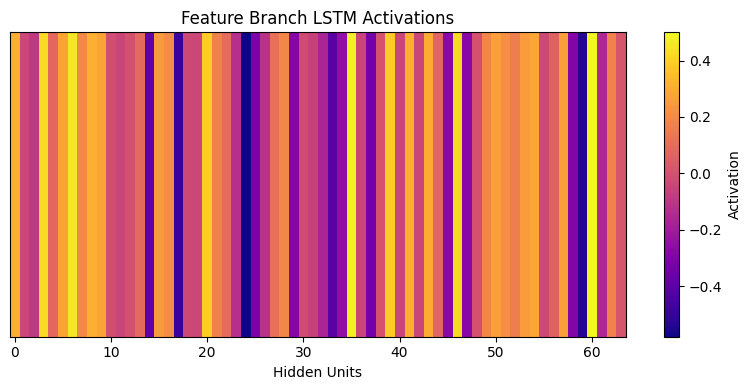

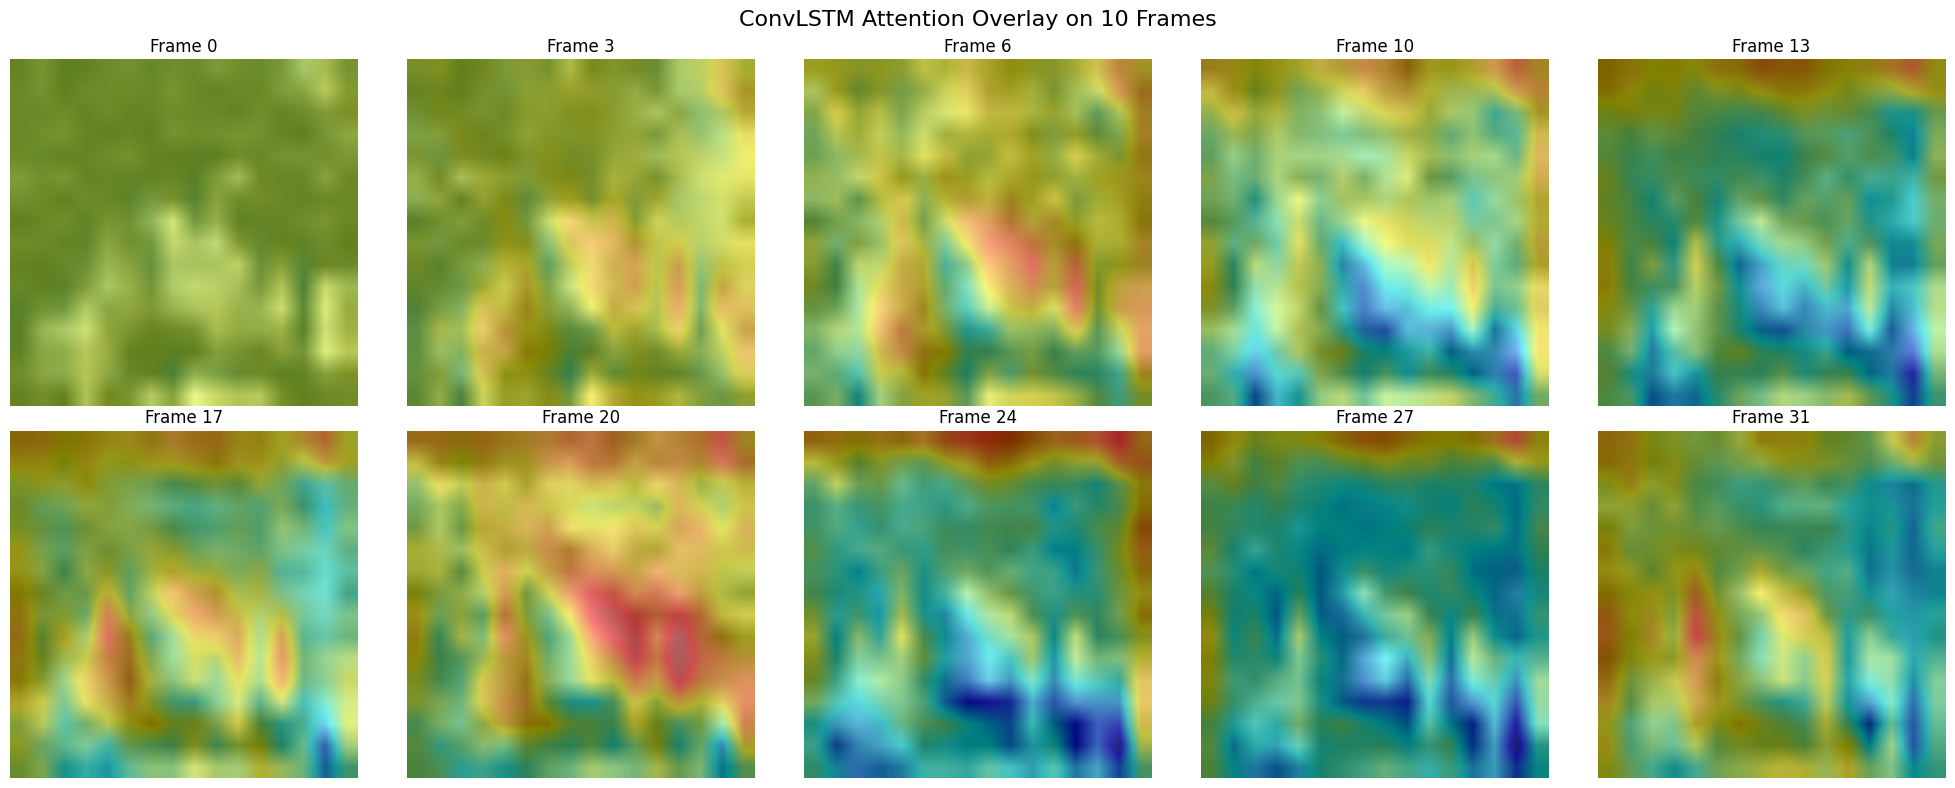

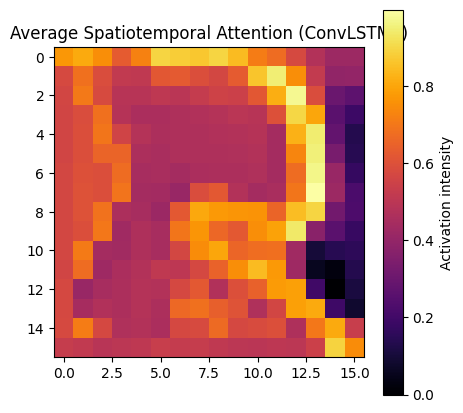

✅ Done! Generated LSTM + ConvLSTM visualizations for 10 frames.


In [2]:
import os, glob, json, cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# -------------------------------
# CONFIG
# -------------------------------
DATA_DIR = "/content/drive/MyDrive/Store/L2Heuristic_labels"
MODEL_PATH = "/content/drive/MyDrive/Store/models/model_w_kfold2/dual_branch_fold4.keras"
FEAT_MEAN_PATH = "/content/drive/MyDrive/Store/models/model_w_kfold2/feat_mean_fold4.npy"
FEAT_STD_PATH  = "/content/drive/MyDrive/Store/models/model_w_kfold2/feat_std_fold4.npy"

WINDOW = 32
STRIDE = 8
LABEL_MODE = "majority"

# -------------------------------
# LOAD MODEL + NORMALIZATION
# -------------------------------
model = tf.keras.models.load_model(MODEL_PATH)
feat_mean = np.load(FEAT_MEAN_PATH)
feat_std  = np.load(FEAT_STD_PATH)

# -------------------------------
# 1️⃣ Load sample heuristic .npz
# -------------------------------
npz_files = sorted(glob.glob(os.path.join(DATA_DIR, "*_heuristic.npz")))
print(f"Found {len(npz_files)} heuristic-labeled files.")

# Choose one (e.g., MOT20-04)
fp = npz_files[0]
d = np.load(fp)
features = d["features"]     # (T, 6)
heatmaps = d["heatmaps"]     # (T, 16, 16)
labels   = d["labels"]       # (T,)
print(f"Loaded: {os.path.basename(fp)} | Features: {features.shape}, Heatmaps: {heatmaps.shape}")

# -------------------------------
# 2️⃣ Make windowed input (like training)
# -------------------------------
def make_windows(features, heatmaps, labels, window=32, stride=8, label_mode="majority"):
    T = len(labels)
    Xf_list, Xh_list, y_list = [], [], []
    for start in range(0, max(T - window + 1, 0), stride):
        end = start + window
        xf = features[start:end]
        xh = heatmaps[start:end][..., None]
        yl = labels[start:end]
        if len(xf) < window:
            continue
        if label_mode == "max":
            y = int(yl.max())
        elif label_mode == "last":
            y = int(yl[-1])
        else:
            y = int((yl.sum() >= (len(yl) / 2)))
        Xf_list.append(xf.astype(np.float32))
        Xh_list.append(xh.astype(np.float32))
        y_list.append(y)
    return np.stack(Xf_list), np.stack(Xh_list), np.array(y_list)

Xf_val, Xh_val, y_val = make_windows(features, heatmaps, labels, window=WINDOW, stride=STRIDE, label_mode=LABEL_MODE)
print("Windowed shapes:", Xf_val.shape, Xh_val.shape, y_val.shape)

# -------------------------------
# 3️⃣ Visualize activations for one window
# -------------------------------
idx = np.random.randint(0, Xf_val.shape[0])
f_in = np.expand_dims((Xf_val[idx] - feat_mean) / (feat_std + 1e-6), 0)
h_in = np.expand_dims(Xh_val[idx], 0)

print(f"✅ Selected sample {idx} | True label: {y_val[idx]}")

# Extract model internals
feat_lstm_layer = [l for l in model.layers if isinstance(l, tf.keras.layers.LSTM)][0]
conv_lstm_layers = [l for l in model.layers if isinstance(l, tf.keras.layers.ConvLSTM2D)]

probe_feat = tf.keras.Model(inputs=model.inputs, outputs=feat_lstm_layer.output)
probe_conv1 = tf.keras.Model(inputs=model.inputs, outputs=conv_lstm_layers[0].output)
probe_conv2 = tf.keras.Model(inputs=model.inputs, outputs=conv_lstm_layers[1].output)

feat_act = probe_feat.predict({"features": f_in, "heatmaps": h_in}, verbose=0)[0]        # (64,)
conv1_act = probe_conv1.predict({"features": f_in, "heatmaps": h_in}, verbose=0)[0]      # (W,16,16,32)
conv2_act = probe_conv2.predict({"features": f_in, "heatmaps": h_in}, verbose=0)[0]      # (16,16,64)

print("Feature LSTM output shape:", feat_act.shape)
print("ConvLSTM1 output shape:", conv1_act.shape)
print("ConvLSTM2 output shape:", conv2_act.shape)

# -------------------------------
# 4️⃣ LSTM Feature Dynamics
# -------------------------------
plt.figure(figsize=(8,4))
plt.imshow(np.expand_dims(feat_act, 1).T, aspect='auto', cmap='plasma')
plt.title("Feature Branch LSTM Activations")
plt.xlabel("Hidden Units")
plt.yticks([])
plt.colorbar(label="Activation")
plt.tight_layout()
plt.show()

# -------------------------------
# 5️⃣ ConvLSTM Visualization (10 frames)
# -------------------------------
T = conv1_act.shape[0]
num_frames = min(10, T)
selected = np.linspace(0, T-1, num_frames).astype(int)

temporal_map = np.mean(conv1_act, axis=-1)  # (W,16,16)
temporal_map = (temporal_map - temporal_map.min()) / (temporal_map.max() - temporal_map.min() + 1e-6)

fig, axs = plt.subplots(2, 5, figsize=(20,8))
axs = axs.ravel()

for i, t in enumerate(selected):
    heat_up = cv2.resize(temporal_map[t], (256,256))
    heat_col = cv2.applyColorMap((heat_up*255).astype(np.uint8), cv2.COLORMAP_JET)
    base = Xh_val[idx][t,...,0]
    base = cv2.resize(base, (256,256))
    base = cv2.cvtColor((base*255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
    overlay = cv2.addWeighted(base, 0.5, heat_col, 0.5, 0)
    axs[i].imshow(overlay[...,::-1])
    axs[i].set_title(f"Frame {t}")
    axs[i].axis("off")

plt.suptitle("ConvLSTM Attention Overlay on 10 Frames", fontsize=16)
plt.tight_layout()
plt.show()

# -------------------------------
# 6️⃣ Average Attention Map
# -------------------------------
avg_att = np.mean(conv2_act, axis=-1)
avg_att = (avg_att - avg_att.min()) / (avg_att.max() - avg_att.min() + 1e-6)

plt.figure(figsize=(5,5))
plt.imshow(avg_att, cmap='inferno')
plt.title("Average Spatiotemporal Attention (ConvLSTM2)")
plt.colorbar(label="Activation intensity")
plt.show()

print("✅ Done! Generated LSTM + ConvLSTM visualizations for 10 frames.")
